In [1]:
from tqdm import tqdm
import numpy as np
from lmfit import minimize, Parameters, fit_report, Model
import pickle
import os
from pyne2001 import get_dm_full
import json
import corner
import sys
import importlib

from astropy.coordinates import SkyCoord
from astropy.cosmology import FlatLambdaCDM, Planck15
import astropy.units as u

from scipy.signal import savgol_filter, resample, correlate
from scipy.fft import fft2, fftshift

import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.ticker import ScalarFormatter

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['cmr10']
rcParams['font.size'] = 25
rcParams['axes.formatter.use_mathtext'] = True
rcParams['axes.unicode_minus'] = False
rcParams['mathtext.fontset'] = 'cm'
rcParams['text.usetex'] = False

sys.path.insert(0,'/arc/home/jfaber/baseband_morphologies/CHIME_DSA_Codetections/scint/utils')

import scinttools_v2 as sct
import burstfittools_v2 as bft


In [2]:
# Load data
name = 'freya_278720455'
basepath = '/arc/home/jfaber/baseband_morphologies/CHIME_DSA_Codetections/CHIME_pkl'
pkl_file = f'{name}_fullstokes_noninterp.pkl'
with open(os.path.join(basepath, pkl_file), 'rb') as file:
    data_pkl = pickle.load(file)  # The file is open only within this block

(1024, 9374)


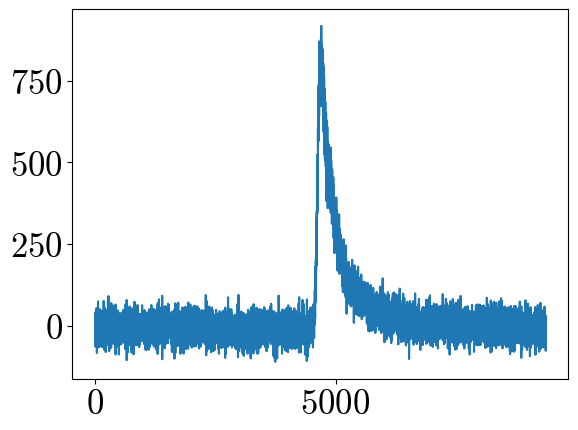

In [3]:
intensity = data_pkl['I']
print(intensity.shape)
plt.plot(np.nansum(intensity, axis=0))

[<Axes: > <Axes: >]
[<Axes: > <Axes: >]


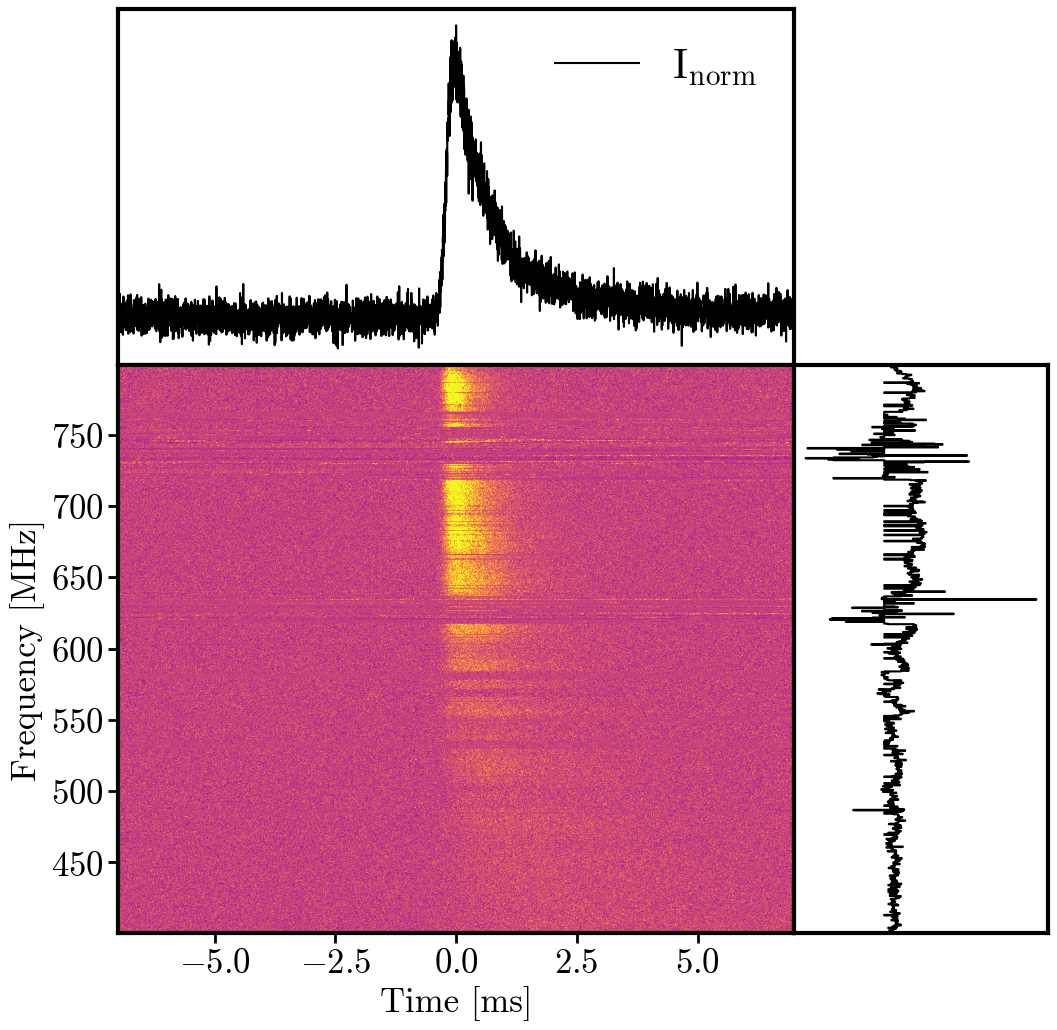

In [10]:
#tres = 32.768e-3 #ms #data['delta_t (ms)']
tres = 2.56e-3
#fres = 0.03051757812 #MHz #data['delta_f (MHz)']
fres = 0.390625
fres_kHz = fres*1e3
f_min = 400.390625
f_max = 799.21875

intensity = data_pkl['I']
outerbound = int(intensity.shape[1] * 2.5/12)

intensity = intensity[:, outerbound:-outerbound]

timeseries = np.nansum(intensity, axis = 0)
timesamples = np.linspace(0, intensity.shape[1]*tres, intensity.shape[1])
timerange = np.abs(timesamples[-1] - timesamples[0])
timesamples_mod = np.linspace(-timerange/2, timerange/2, len(timesamples))
timeshift = -1 * int(timesamples_mod[np.argmax(timeseries)] / tres)

intensity = np.roll(intensity, timeshift, axis = 1)
intensity_norm = intensity / np.nanmax(intensity)
spectrum = np.nansum(intensity, axis = 1)
spectrum_norm = spectrum / np.nanmax(spectrum)
freqsamples = np.linspace(f_min, f_max, intensity.shape[0])
timeseries = np.nansum(intensity, axis = 0)
timeseries_norm = timeseries / np.nanmax(timeseries)

from matplotlib.colors import LogNorm

fig, axes = plt.subplots(
        nrows=2, ncols=2, sharex=False, sharey=False, 
        gridspec_kw={'height_ratios':[1.25,2], 'width_ratios':[2, 0.75]},
        figsize = (12, 12))

# Increase border thickness
current_axes = plt.gca()
for ax_row in axes:
    for ax in ax_row:
        ax.spines['top'].set_linewidth(3)
        ax.spines['bottom'].set_linewidth(3)
        ax.spines['left'].set_linewidth(3)
        ax.spines['right'].set_linewidth(3)
for ax_row in axes:
    print(ax_row)
    for ax in ax_row:
        ax.tick_params(which='both', width=2)
        ax.tick_params(which='major', length=7)
        ax.tick_params(which='minor', length=5)
        ax.tick_params(which='minor', axis = 'y', length=5)

axes[0, 0].step(timesamples_mod, timeseries_norm, where = 'mid', c = 'k', alpha = 1, label = 'I$_{\mathrm{norm}}$')
axes[0, 0].set_yticks([0, 1])
axes[0, 0].tick_params(axis='x',
        which='both', 
        bottom=False, 
        top=False, 
        labelbottom=False,
        width=2)
axes[0, 0].set_yticks([])
axes[0, 0].set_xlim(timesamples_mod[0], timesamples_mod[-1])
axes[0, 0].legend(loc = 'upper right', fontsize = 30, frameon = False)

mean = np.nanmean(intensity_norm)
std = np.nanstd(intensity_norm)
axes[1, 0].imshow(intensity_norm, vmin = mean - 2*std, vmax = mean + 2*std, extent = [timesamples_mod[0], timesamples_mod[-1], freqsamples[0], freqsamples[-1]], cmap = 'plasma', aspect = 'auto') 
axes[1, 0].set_ylabel('Frequency [MHz]')
axes[1, 0].set_xlabel('Time [ms]')
axes[1, 0].tick_params(which='both', width=2)
axes[1, 0].tick_params(which='major', length=7)
axes[1, 0].tick_params(which='minor', length=5)
axes[1, 0].tick_params(which='minor', axis = 'y', length=5)

axes[0, 1].axis('off')
axes[0, 1].set_visible(False)

axes[1, 1].step(np.flip(spectrum_norm), freqsamples, where='pre', c = 'k', alpha = 1, label = 'I$_{\mathrm{norm}}$')
axes[1, 1].tick_params(axis='y',
        which='both', 
        left=False, 
        right=False, 
        labelleft=False,
        width=2)
axes[1, 1].set_xticks([])
axes[1, 1].set_ylim(freqsamples[0], freqsamples[-1])
#axes[2].legend(loc = 'upper right', fontsize = 30, frameon = False)

#axes[1].set_xlim(40, 150)
plt.subplots_adjust(hspace=0)
plt.subplots_adjust(wspace=0)

fig.savefig(f'/arc/home/jfaber/baseband_morphologies/CHIME_DSA_Codetections/scint/figures/{name.split("_")[0]}/{name}_fullres_wfall.pdf', bbox_inches = 'tight')

plt.show()

In [16]:
f_factor = 32
t_factor = 8
intensity_ds = bft.downsample_data(intensity, f_factor = f_factor, t_factor = t_factor)

Power Shape (frequency axis): 1024
Power Shape (time axis): 5470
Nearest Multiple To Downsampling Factor (frequency): 1024
Nearest Multiple To Downsampling Factor (time): 5464
Downsampled Data Shape: (32, 683)


[<Axes: > <Axes: >]
[<Axes: > <Axes: >]


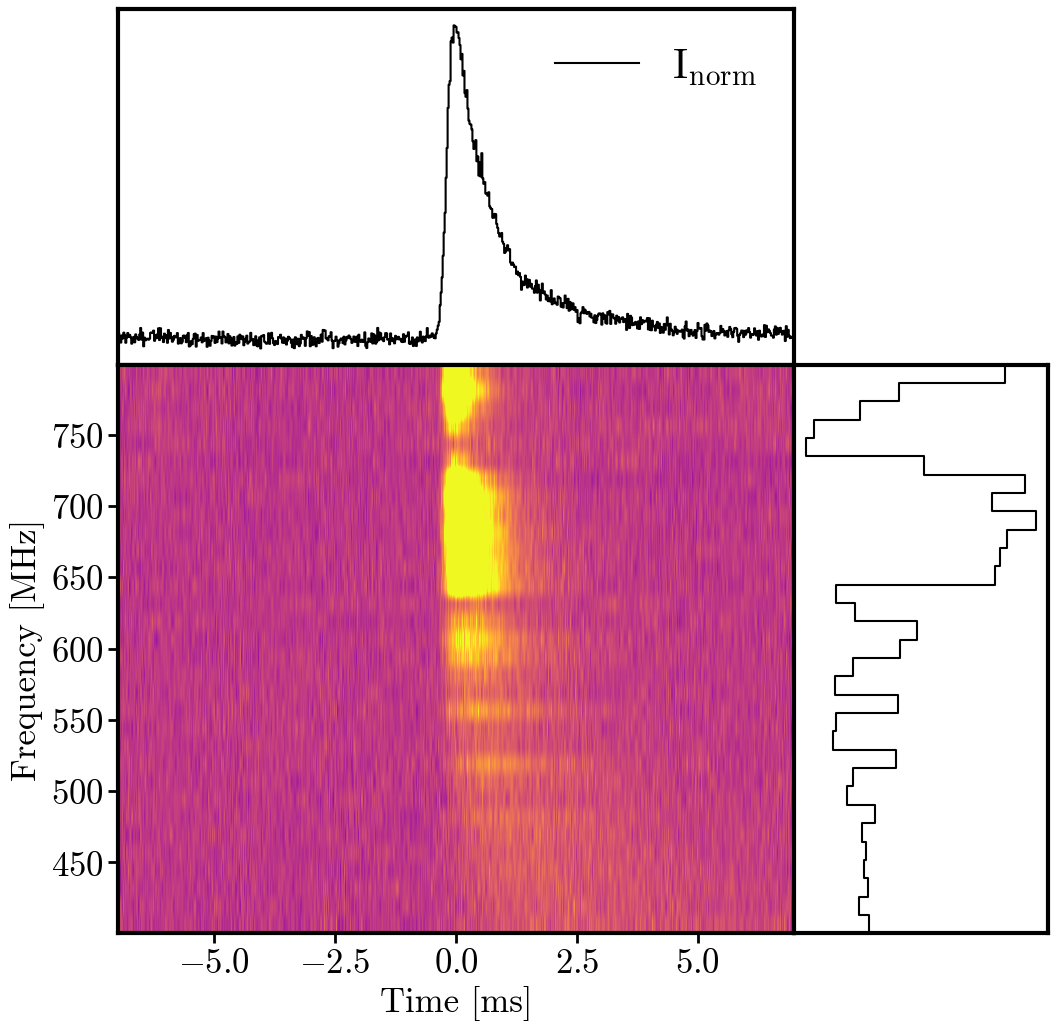

In [17]:
fres_ds = fres * f_factor
tres_ds = tres * t_factor

intensity_ds_norm = intensity_ds / np.max(intensity_ds)
timeseries_ds = np.nansum(intensity_ds, axis = 0)
timeseries_ds = timeseries_ds - np.nanmean(timeseries_ds)
timeseries_ds = timeseries_ds / np.nanstd(timeseries_ds)
timeseries_ds_norm = timeseries_ds / np.max(timeseries_ds)
timesamples_ds = np.linspace(0, intensity_ds.shape[1]*tres_ds, intensity_ds.shape[1])
timerange_ds = np.abs(timesamples_ds[-1] - timesamples_ds[0])
timesamples_mod_ds = np.linspace(-timerange_ds/2, timerange_ds/2, len(timesamples_ds))
spectrum_ds = np.nansum(intensity_ds, axis = 1)
spectrum_ds = spectrum_ds - np.nanmean(spectrum_ds)
spectrum_ds = spectrum_ds / np.nanstd(spectrum_ds)
spectrum_ds_norm = spectrum_ds / np.max(spectrum_ds)
freqsamples_ds = np.linspace(f_min, f_max, intensity_ds.shape[0])

#spectrum = np.nansum(intensity_ds, axis = 1)
#timeseries = np.nansum(intensity_ds, axis = 0)

from matplotlib.colors import LogNorm

fig, axes = plt.subplots(
        nrows=2, ncols=2, sharex=False, sharey=False, 
        gridspec_kw={'height_ratios':[1.25,2], 'width_ratios':[2, 0.75]},
        figsize = (12, 12))

# Increase border thickness
current_axes = plt.gca()
for ax_row in axes:
    for ax in ax_row:
        ax.spines['top'].set_linewidth(3)
        ax.spines['bottom'].set_linewidth(3)
        ax.spines['left'].set_linewidth(3)
        ax.spines['right'].set_linewidth(3)
for ax_row in axes:
    print(ax_row)
    for ax in ax_row:
        ax.tick_params(which='both', width=2)
        ax.tick_params(which='major', length=7)
        ax.tick_params(which='minor', length=5)
        ax.tick_params(which='minor', axis = 'y', length=5)

axes[0, 0].step(timesamples_mod_ds, timeseries_ds_norm, where = 'mid', c = 'k', alpha = 1, label = 'I$_{\mathrm{norm}}$')
#axes[0, 0].set_yticks([0, 1])
axes[0, 0].tick_params(axis='x',
        which='both', 
        bottom=False, 
        top=False, 
        labelbottom=False,
        width=2)
axes[0, 0].set_yticks([])
axes[0, 0].set_xlim(timesamples_mod_ds[0], timesamples_mod_ds[-1])
axes[0, 0].legend(loc = 'upper right', fontsize = 30, frameon = False)

mean_ds = np.nanmean(intensity_ds_norm)
std_ds = np.nanstd(intensity_ds_norm)
axes[1, 0].imshow(intensity_ds_norm, vmin = mean_ds - 3*std_ds, vmax = mean_ds + 3*std_ds, extent = [timesamples_mod_ds[0], timesamples_mod_ds[-1], freqsamples_ds[0], freqsamples_ds[-1]], cmap = 'plasma', aspect = 'auto')#, interpolation='nearest') 
#axes[1, 0].imshow(intensity_ds_norm, extent = [timesamples_mod_ds[0], timesamples_mod_ds[-1], freqsamples_ds[0], freqsamples_ds[-1]], cmap = 'plasma', aspect = 'auto')#, interpolation='nearest') 
axes[1, 0].set_ylabel('Frequency [MHz]')
axes[1, 0].set_xlabel('Time [ms]')
axes[1, 0].tick_params(which='both', width=2)
axes[1, 0].tick_params(which='major', length=7)
axes[1, 0].tick_params(which='minor', length=5)
axes[1, 0].tick_params(which='minor', axis = 'y', length=5)

axes[0, 1].axis('off')
axes[0, 1].set_visible(False)

axes[1, 1].step(np.flip(spectrum_ds_norm), freqsamples_ds, where='pre', c = 'k', alpha = 1, label = 'I$_{\mathrm{norm}}$')
axes[1, 1].tick_params(axis='y',
        which='both', 
        left=False, 
        right=False, 
        labelleft=False,
        width=2)
axes[1, 1].set_xticks([])
axes[1, 1].set_ylim(freqsamples_ds[0], freqsamples_ds[-1])
#axes[2].legend(loc = 'upper right', fontsize = 30, frameon = False)

#axes[1].set_xlim(40, 150)
plt.subplots_adjust(hspace=0)
plt.subplots_adjust(wspace=0)

fig.savefig(f'{name}_lowres_wfall.pdf', bbox_inches = 'tight')

plt.show()

In [18]:
importlib.reload(bft)

<module 'burstfittools_v2' from '/arc/home/jfaber/baseband_morphologies/CHIME_DSA_Codetections/scint/utils/burstfittools_v2.py'>

In [19]:
n_channels = intensity_ds.shape[0]
n_samples = intensity_ds.shape[1]

# Create time array (ms)
time = np.linspace(0, n_samples*tres_ds, n_samples)

# Create frequency array with 128 channels
f_b = 0.400390625
f_t = 0.79921875
freq = np.linspace(f_b, f_t, n_channels)

# Set parameters for Model 3
#c0 = 1.0  # Reference flux at reference frequency
#spectral_index = 2.5
#t0 = 1.0  # ms
dm_init = 0.0
#DM_err = 0.0
#zeta = 0.08
#tau_1GHz = 0.6
#alpha = 4.0

# Parameters array for model 3
#params = [c0, spectral_index, t0, DM_err, zeta, tau_1GHz, alpha]

# Initialize the model and data
#data = np.zeros((N_channels, N_time_samples))
model_instance = bft.FRBModel(intensity_ds_norm, time, freq, dm_init)

# Add Gaussian noise to the simulated data
#np.random.seed(42)  # For reproducibility
#noise_level = 0.05 * np.max(simulated_data)  # Adjust noise level as needed
#noise = noise_level * np.random.randn(*simulated_data.shape)
#simulated_data_noisy = simulated_data + noise
#simulated_data_timeseries = simulated_data_noisy.sum(0) / np.max(simulated_data_noisy.sum(0))

Noise Sigma:  [0.01879314 0.01892354 0.01672174 0.01734938 0.01680547 0.01805641
 0.01675923 0.01764723 0.01657603 0.01721961 0.01681848 0.01897506
 0.01898959 0.01392271 0.01844495 0.01921656 0.01824907 0.01580863
 0.01868266 0.01874183 0.02007172 0.01540878 0.02096572 0.01921407
 0.01926009 0.01701488 0.01941415 0.01937941 0.02198766 0.0214832
 0.02146309 0.02335843]


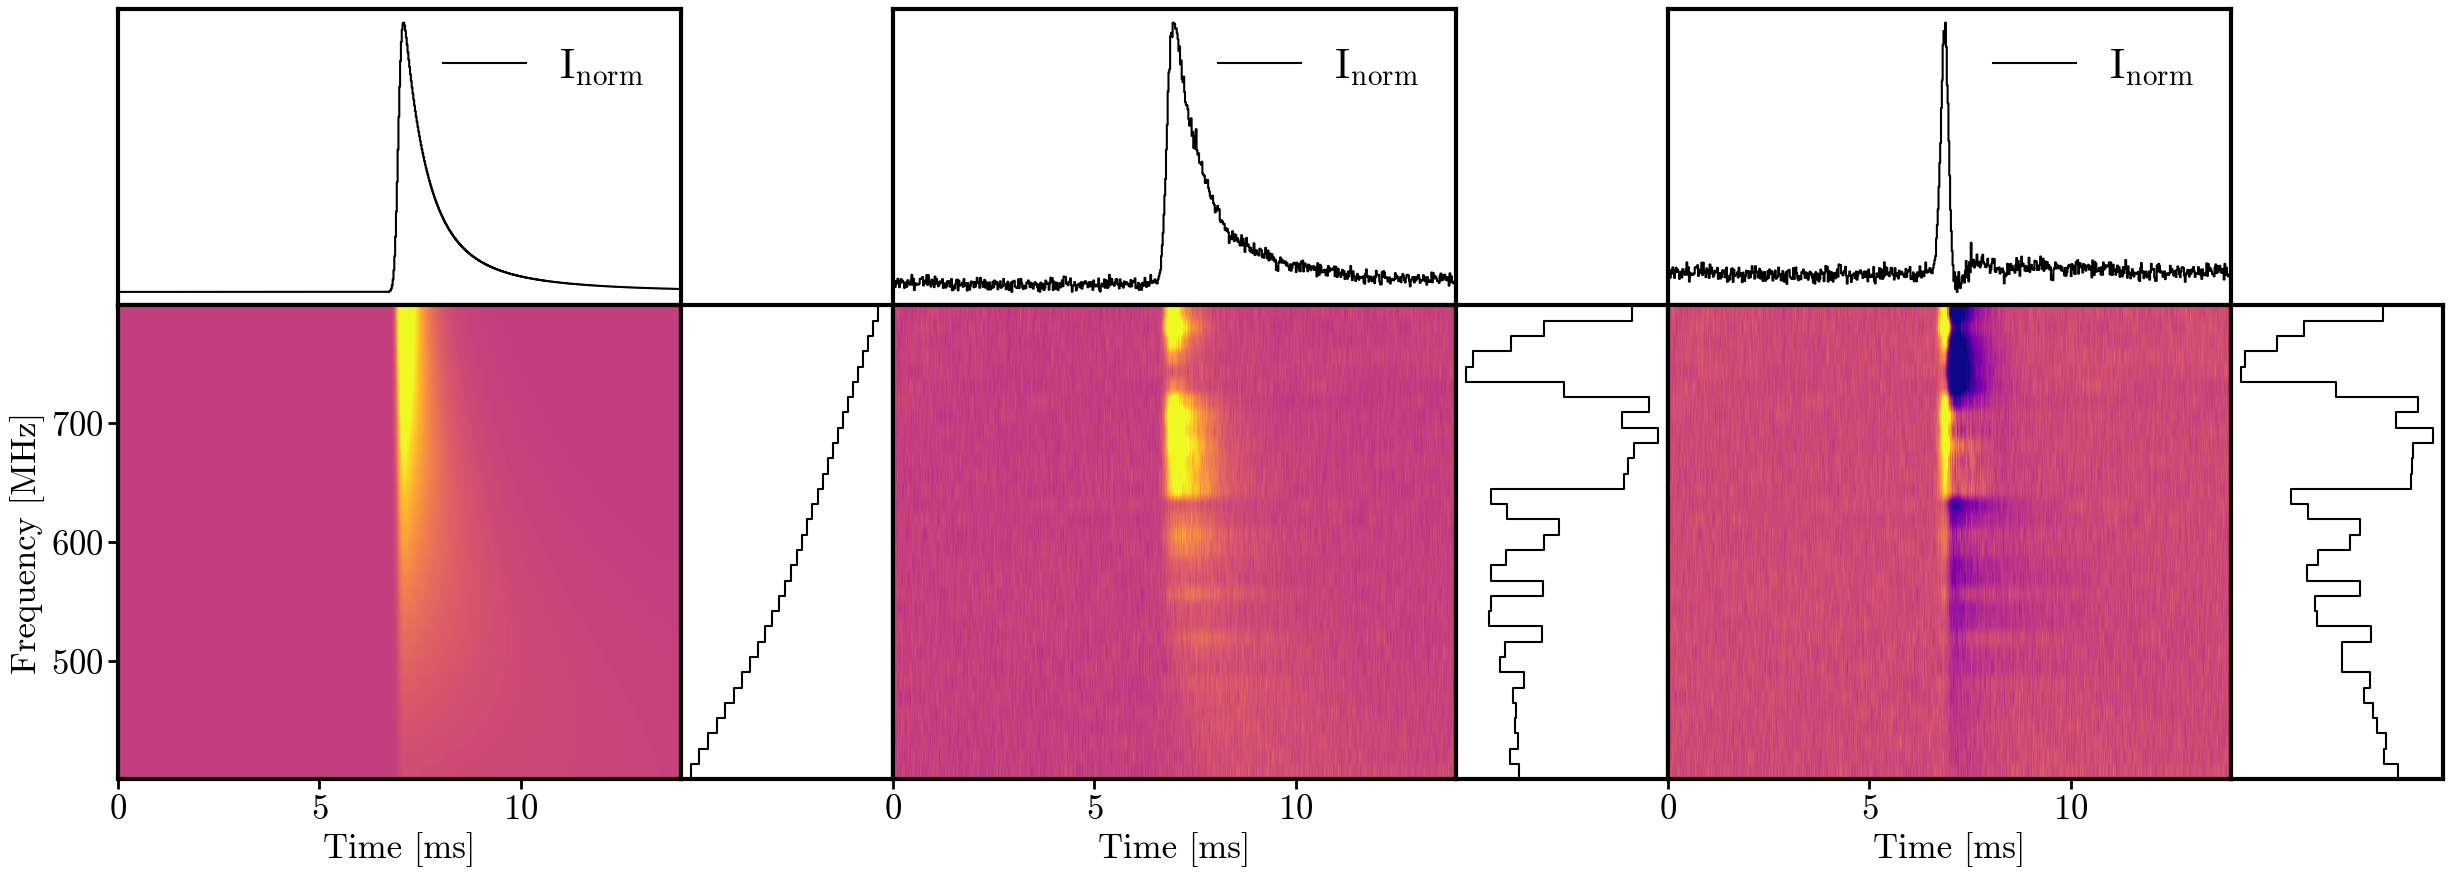

In [20]:
# --- (Assuming the simulated data and real data arrays have already been defined) ---
from scipy.signal import savgol_filter
# Generate simulated data (as in your original code)
c0_init = np.max(np.sum(intensity_ds_norm, axis=1))# / intensity_ds_norm.shape[1]
t0_init = timesamples_ds[np.argmax(np.sum(savgol_filter(intensity_ds_norm, 11, 3), axis=0))]
gamma_init = 1
#DM_err_init = 0.0
zeta_init = 0.075
tau_init = 0.15
#alpha_init = 4.0

model_type = 'model3'
if model_type == 'model0':
    #sim_params = [c0_init, t0_init, gamma_init, DM_err_init, 0., 0.]
    sim_params = [c0_init, t0_init, gamma_init, 0., 0.]
elif model_type == 'model1':
    #sim_params = [c0_init, t0_init, gamma_init, DM_err_init, zeta_init, 0.]
    sim_params = [c0_init, t0_init, gamma_init, zeta_init, 0.]
elif model_type == 'model2':
    #sim_params = [c0_init, t0_init, gamma_init, DM_err_init, tau_init, alpha_init, 0.]
    #sim_params = [c0_init, t0_init, gamma_init, DM_err_init, tau_init, 0.]
    sim_params = [c0_init, t0_init, gamma_init, tau_init, 0.]
elif model_type == 'model3':
    #sim_params = [c0_init, t0_init, gamma_init, DM_err_init, zeta_init, tau_init, alpha_init]
    #sim_params = [c0_init, t0_init, gamma_init, DM_err_init, zeta_init, tau_init]
    sim_params = [c0_init, t0_init, gamma_init, zeta_init, tau_init]

simulated_data = model_instance.model(sim_params, model_type=model_type)
simulated_data_norm = simulated_data / np.max(simulated_data)

sim_fres = fres_ds
sim_tres = tres_ds
sim_timeseries = np.nansum(simulated_data, axis=0)
sim_timeseries_norm = sim_timeseries / np.max(sim_timeseries)
sim_timesamples = np.linspace(0, simulated_data.shape[1]*sim_tres, simulated_data.shape[1])
sim_timerange = np.abs(sim_timesamples[-1] - sim_timesamples[0])
sim_timesamples_mod = np.linspace(-sim_timerange/2, sim_timerange/2, len(sim_timesamples))
sim_spectrum = np.nansum(simulated_data, axis=1)
sim_spectrum_norm = sim_spectrum / np.max(sim_spectrum)
sim_freqsamples = np.linspace(f_min, f_max, simulated_data.shape[0])

# Compute residuals and residual spectrum
intensity_rsdl = intensity_ds_norm - simulated_data_norm
timeseries_rsdl = timeseries_ds_norm - sim_timeseries_norm
rsdl_spectrum = np.nansum(intensity_rsdl, axis=1)
rsdl_spectrum_norm = rsdl_spectrum / np.max(rsdl_spectrum)

# Precompute means and stds for imshow scaling
sim_mean = np.nanmean(simulated_data_norm)
sim_std = np.nanstd(simulated_data_norm)
mean_ds = np.nanmean(intensity_ds_norm)
std_ds = np.nanstd(intensity_ds_norm)
mean_rsdl = np.nanmean(intensity_rsdl)
std_rsdl = np.nanstd(intensity_rsdl)

# Create a figure with 2 rows x 6 columns:
# Columns 0-1: Panel 1 (Simulated/Model)
# Columns 2-3: Panel 2 (Real Data)
# Columns 4-5: Panel 3 (Residual)
fig, axes = plt.subplots(
    nrows=2, ncols=6, sharex=False, sharey=False,
    gridspec_kw={'height_ratios': [1.25, 2],
                 'width_ratios': [2, 0.75, 2, 0.75, 2, 0.75]},
    figsize=(30, 10)
)

# Increase border thickness and set tick parameters for every axis
for ax_row in axes:
    for ax in ax_row:
        ax.spines['top'].set_linewidth(3)
        ax.spines['bottom'].set_linewidth(3)
        ax.spines['left'].set_linewidth(3)
        ax.spines['right'].set_linewidth(3)
        ax.tick_params(which='both', width=2)
        ax.tick_params(which='major', length=7)
        ax.tick_params(which='minor', length=5)
        ax.tick_params(which='minor', axis='y', length=5)

# ----- PANEL 1: Simulated Data (Model) -----
# Timeseries (top left of panel 1: column 0)
axes[0, 0].step(sim_timesamples, sim_timeseries_norm, where='mid', c='k', alpha=1, label='I$_{\mathrm{norm}}$')
axes[0, 0].set_yticks([])
axes[0, 0].tick_params(axis='x', bottom=False, top=False, labelbottom=False)
axes[0, 0].set_xlim(sim_timesamples[0], sim_timesamples[-1])
axes[0, 0].legend(loc='upper right', fontsize=30, frameon=False)

# Waterfall (bottom left of panel 1: column 0)
axes[1, 0].imshow(simulated_data_norm,
                   vmin=sim_mean - 6*sim_std, vmax=sim_mean + 6*sim_std,
                   extent=[sim_timesamples[0], sim_timesamples[-1], sim_freqsamples[0], sim_freqsamples[-1]],
                   cmap='plasma', aspect='auto')
axes[1, 0].set_ylabel('Frequency [MHz]')
axes[1, 0].set_xlabel('Time [ms]')

# Spectrum (bottom right of panel 1: column 1)
axes[1, 1].step(np.flip(sim_spectrum_norm), sim_freqsamples, where='pre', c='k', alpha=1, label='I$_{\mathrm{norm}}$')
#axes[1, 1].set_xlabel('Intensity')
axes[1, 1].set_xticks([])
axes[1, 1].set_ylim(sim_freqsamples[0], sim_freqsamples[-1])
axes[1, 1].tick_params(axis='y', left=False, right=False, labelleft=False)

# Hide the unused top axis for spectrum (column 1)
axes[0, 1].axis('off')
axes[0, 1].set_visible(False)

# ----- PANEL 2: Real Data -----
# Timeseries (top left of panel 2: column 2)
axes[0, 2].step(timesamples_ds, timeseries_ds_norm, where='mid', c='k', alpha=1, label='I$_{\mathrm{norm}}$')
axes[0, 2].set_yticks([])
axes[0, 2].tick_params(axis='x', bottom=False, top=False, labelbottom=False)
axes[0, 2].set_xlim(timesamples_ds[0], timesamples_ds[-1])
axes[0, 2].legend(loc='upper right', fontsize=30, frameon=False)

# Waterfall (bottom left of panel 2: column 2)
axes[1, 2].imshow(intensity_ds_norm,
                   vmin=mean_ds - 6*std_ds, vmax=mean_ds + 6*std_ds,
                   extent=[timesamples_ds[0], timesamples_ds[-1], freqsamples_ds[0], freqsamples_ds[-1]],
                   cmap='plasma', aspect='auto')
#axes[1, 2].set_ylabel('Frequency [MHz]')
axes[1, 2].set_yticks([])
axes[1, 2].set_xlabel('Time [ms]')

# Spectrum (bottom right of panel 2: column 3)
axes[1, 3].step(np.flip(spectrum_ds_norm), freqsamples_ds, where='pre', c='k', alpha=1, label='I$_{\mathrm{norm}}$')
#axes[1, 3].set_xlabel('Intensity')
axes[1, 3].set_xticks([])
axes[1, 3].set_ylim(freqsamples_ds[0], freqsamples_ds[-1])
axes[1, 3].tick_params(axis='y', left=False, right=False, labelleft=False)

# Hide the unused top axis for spectrum (column 3)
axes[0, 3].axis('off')
axes[0, 3].set_visible(False)

# ----- PANEL 3: Residuals -----
# Timeseries residual (top left of panel 3: column 4)
axes[0, 4].step(sim_timesamples, timeseries_rsdl, where='mid', c='k', alpha=1, label='I$_{\mathrm{norm}}$')
axes[0, 4].set_yticks([])
axes[0, 4].tick_params(axis='x', bottom=False, top=False, labelbottom=False)
axes[0, 4].set_xlim(sim_timesamples[0], sim_timesamples[-1])
axes[0, 4].legend(loc='upper right', fontsize=30, frameon=False)

# Waterfall residual (bottom left of panel 3: column 4)
axes[1, 4].imshow(intensity_rsdl,
                   vmin=mean_rsdl - 6*std_rsdl, vmax=mean_rsdl + 6*std_rsdl,
                   extent=[sim_timesamples[0], sim_timesamples[-1], sim_freqsamples[0], sim_freqsamples[-1]],
                   cmap='plasma', aspect='auto')
#axes[1, 4].set_ylabel('Frequency [MHz]')
axes[1, 4].set_yticks([])
axes[1, 4].set_xlabel('Time [ms]')

# Spectrum for residuals (bottom right of panel 3: column 5)
axes[1, 5].step(np.flip(rsdl_spectrum_norm), sim_freqsamples, where='pre', c='k', alpha=1, label='I$_{\mathrm{norm}}$')
#axes[1, 5].set_xlabel('Intensity')
axes[1, 5].set_xticks([])
axes[1, 5].set_ylim(sim_freqsamples[0], sim_freqsamples[-1])
axes[1, 5].tick_params(axis='y', left=False, right=False, labelleft=False)

# Hide the unused top axis for spectrum (column 5)
axes[0, 5].axis('off')
axes[0, 5].set_visible(False)
plt.subplots_adjust(hspace=0, wspace=0)

fig.savefig(f'{name}_initmodel_threepanel.pdf', bbox_inches = 'tight')

plt.show()


In [22]:
# Fit the models
prior_bounds = {
        'c0': (0, 2),  # Adjusted as per prior
        't0': (t0_init - 2, t0_init + 2),
        'spectral_index': (1, 3),
        #'DM_err': (-0.1, 0.1),
        'zeta': (0.1, 0.2),
        'tau_1GHz': (0.05, 0.5)
        #'alpha': (3.999999, 4.000001)
    }

nsteps = 1000

results, best_model = bft.fit_models(model_instance, sim_params, prior_bounds, numsteps=nsteps, fit_m0=False, fit_m1=False, fit_m2=False, fit_m3=True)
print('\n')
print(f"The best-fitting model is: {best_model}")
print('\n')
print(results)

Check Prior Bounds:  {'c0': (0, 2), 't0': (4.973409970674487, 8.973409970674487), 'spectral_index': (1, 3), 'zeta': (0.1, 0.2), 'tau_1GHz': (0.05, 0.5)}
Fitting Model 3


100%|██████████| 1000/1000 [03:32<00:00,  4.71it/s]

Difference in BIC is greater than 6, the best model is model3!
Difference in BIC is greater than 6, the best model is model3!
Difference in BIC is greater than 6, the best model is model3!
Difference in BIC is greater than 6, the best model is model3!
Best model is model3


The best-fitting model is: model3


{'model0': {'sampler': nan, 'BIC': nan, 'lnL_max': nan, 'k': nan}, 'model1': {'sampler': nan, 'BIC': nan, 'lnL_max': nan, 'k': nan}, 'model2': {'sampler': nan, 'BIC': nan, 'lnL_max': nan, 'k': nan}, 'model3': {'sampler': <emcee.ensemble.EnsembleSampler object at 0x7f0bf800fb80>, 'BIC': -33827.2296138859, 'lnL_max': 16938.59538384888, 'k': 5}}


In [23]:
# Extract the sampler
best_sampler = results[best_model]['sampler']

print("Mean acceptance fraction (should be 0.2-0.5):", np.mean(best_sampler.acceptance_fraction))

# Check for NaN or Inf in Sampler
log_probs = best_sampler.get_log_prob()
if np.any(~np.isfinite(log_probs)):
    print("Found NaN or Inf in log-probabilities.")

#samples = best_sampler.get_chain(flat=True)
# Discard burn-in samples
burn_in = nsteps // 2
# Extract the samples
samples = best_sampler.get_chain(discard=burn_in, flat=True)
# Extract the log probability
log_prob = best_sampler.get_log_prob(discard=burn_in, flat=True)

# Determine the indices of the relevant parameters
if best_model == 'model0':
    #param_indices = [0, 1, 2, 3]  # c0, spectral_index, t0, DM_err
    param_indices = [0, 1, 2]
elif best_model == 'model1':
    #param_indices = [0, 1, 2, 3, 4]  # + zeta
    param_indices = [0, 1, 2, 3]
elif best_model == 'model2':
    #param_indices = [0, 1, 2, 3, 4, 5]  # + tau_1GHz, alpha
    #param_indices = [0, 1, 2, 3, 4]
    param_indices = [0, 1, 2, 3]
elif best_model == 'model3':
    #param_indices = [0, 1, 2, 3, 4, 5, 6]  # + zeta, tau_1GHz, alpha
    #param_indices = [0, 1, 2, 3, 4, 5]
    param_indices = [0, 1, 2, 3, 4]

# Extract the relevant samples
relevant_samples = samples[:, param_indices]

# Extract the relevant true parameter values
#truths = [params[i] for i in param_indices]

# Define labels for the parameters
#labels = ['c0', 't0', 'spectral_index', 'DM_err']
labels = ['c0', 't0', 'spectral_index']
if best_model in ['model1', 'model3']:
    labels.append('zeta')
if best_model in ['model2', 'model3']:
    #labels.extend(['tau_1GHz', 'alpha'])
    labels.extend(['tau_1GHz'])

# Plot trace plots to assess convergence
#ndim = relevant_samples.shape[1]
#fig, axes = plt.subplots(ndim, figsize=(15, 10), sharex=True)
#for i in range(ndim):
#    axes[i].plot(samples[:, i], "k", alpha=0.3)
#    axes[i].set_ylabel(labels[i])
#axes[-1].set_xlabel("Step number")
#plt.show()

Mean acceptance fraction (should be 0.2-0.5): 0.45396000000000003


In [24]:
# Calculate parameter estimates and their uncertainties
best_fit_params = []
best_fit_params_dict = {}
for i, label in enumerate(labels):
    mcmc = np.percentile(samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    print(f"{label} = {mcmc[1]:.3f} (+{q[1]:.3f}, -{q[0]:.3f})")
    best_fit_params.append(mcmc[1])
    best_fit_params_dict[f'{label}'] = (mcmc[1], +q[1], -q[0])

# Generate simulated data
initial_params = {}
initial_params['c0_init'] = c0_init
initial_params['t0_init'] = t0_init
initial_params['gamma_init'] = gamma_init
#initial_params['DM_err_init'] = DM_err_init
initial_params['zeta_init'] = zeta_init
initial_params['tau_init'] = tau_init
#initial_params['alpha_init'] = alpha_init

best_fit_params_dict['initial_params'] = initial_params
best_fit_params_dict['prior_bounds'] = prior_bounds


c0 = 0.006 (+0.000, -0.000)
t0 = 6.826 (+0.001, -0.001)
spectral_index = 1.001 (+0.002, -0.001)
zeta = 0.102 (+0.001, -0.001)
tau_1GHz = 0.135 (+0.001, -0.001)


Best Fit Params: [0.005601161250638399, 6.826224485332753, 1.0011858056830092, 0.10198158448549827, 0.13494343828349623]


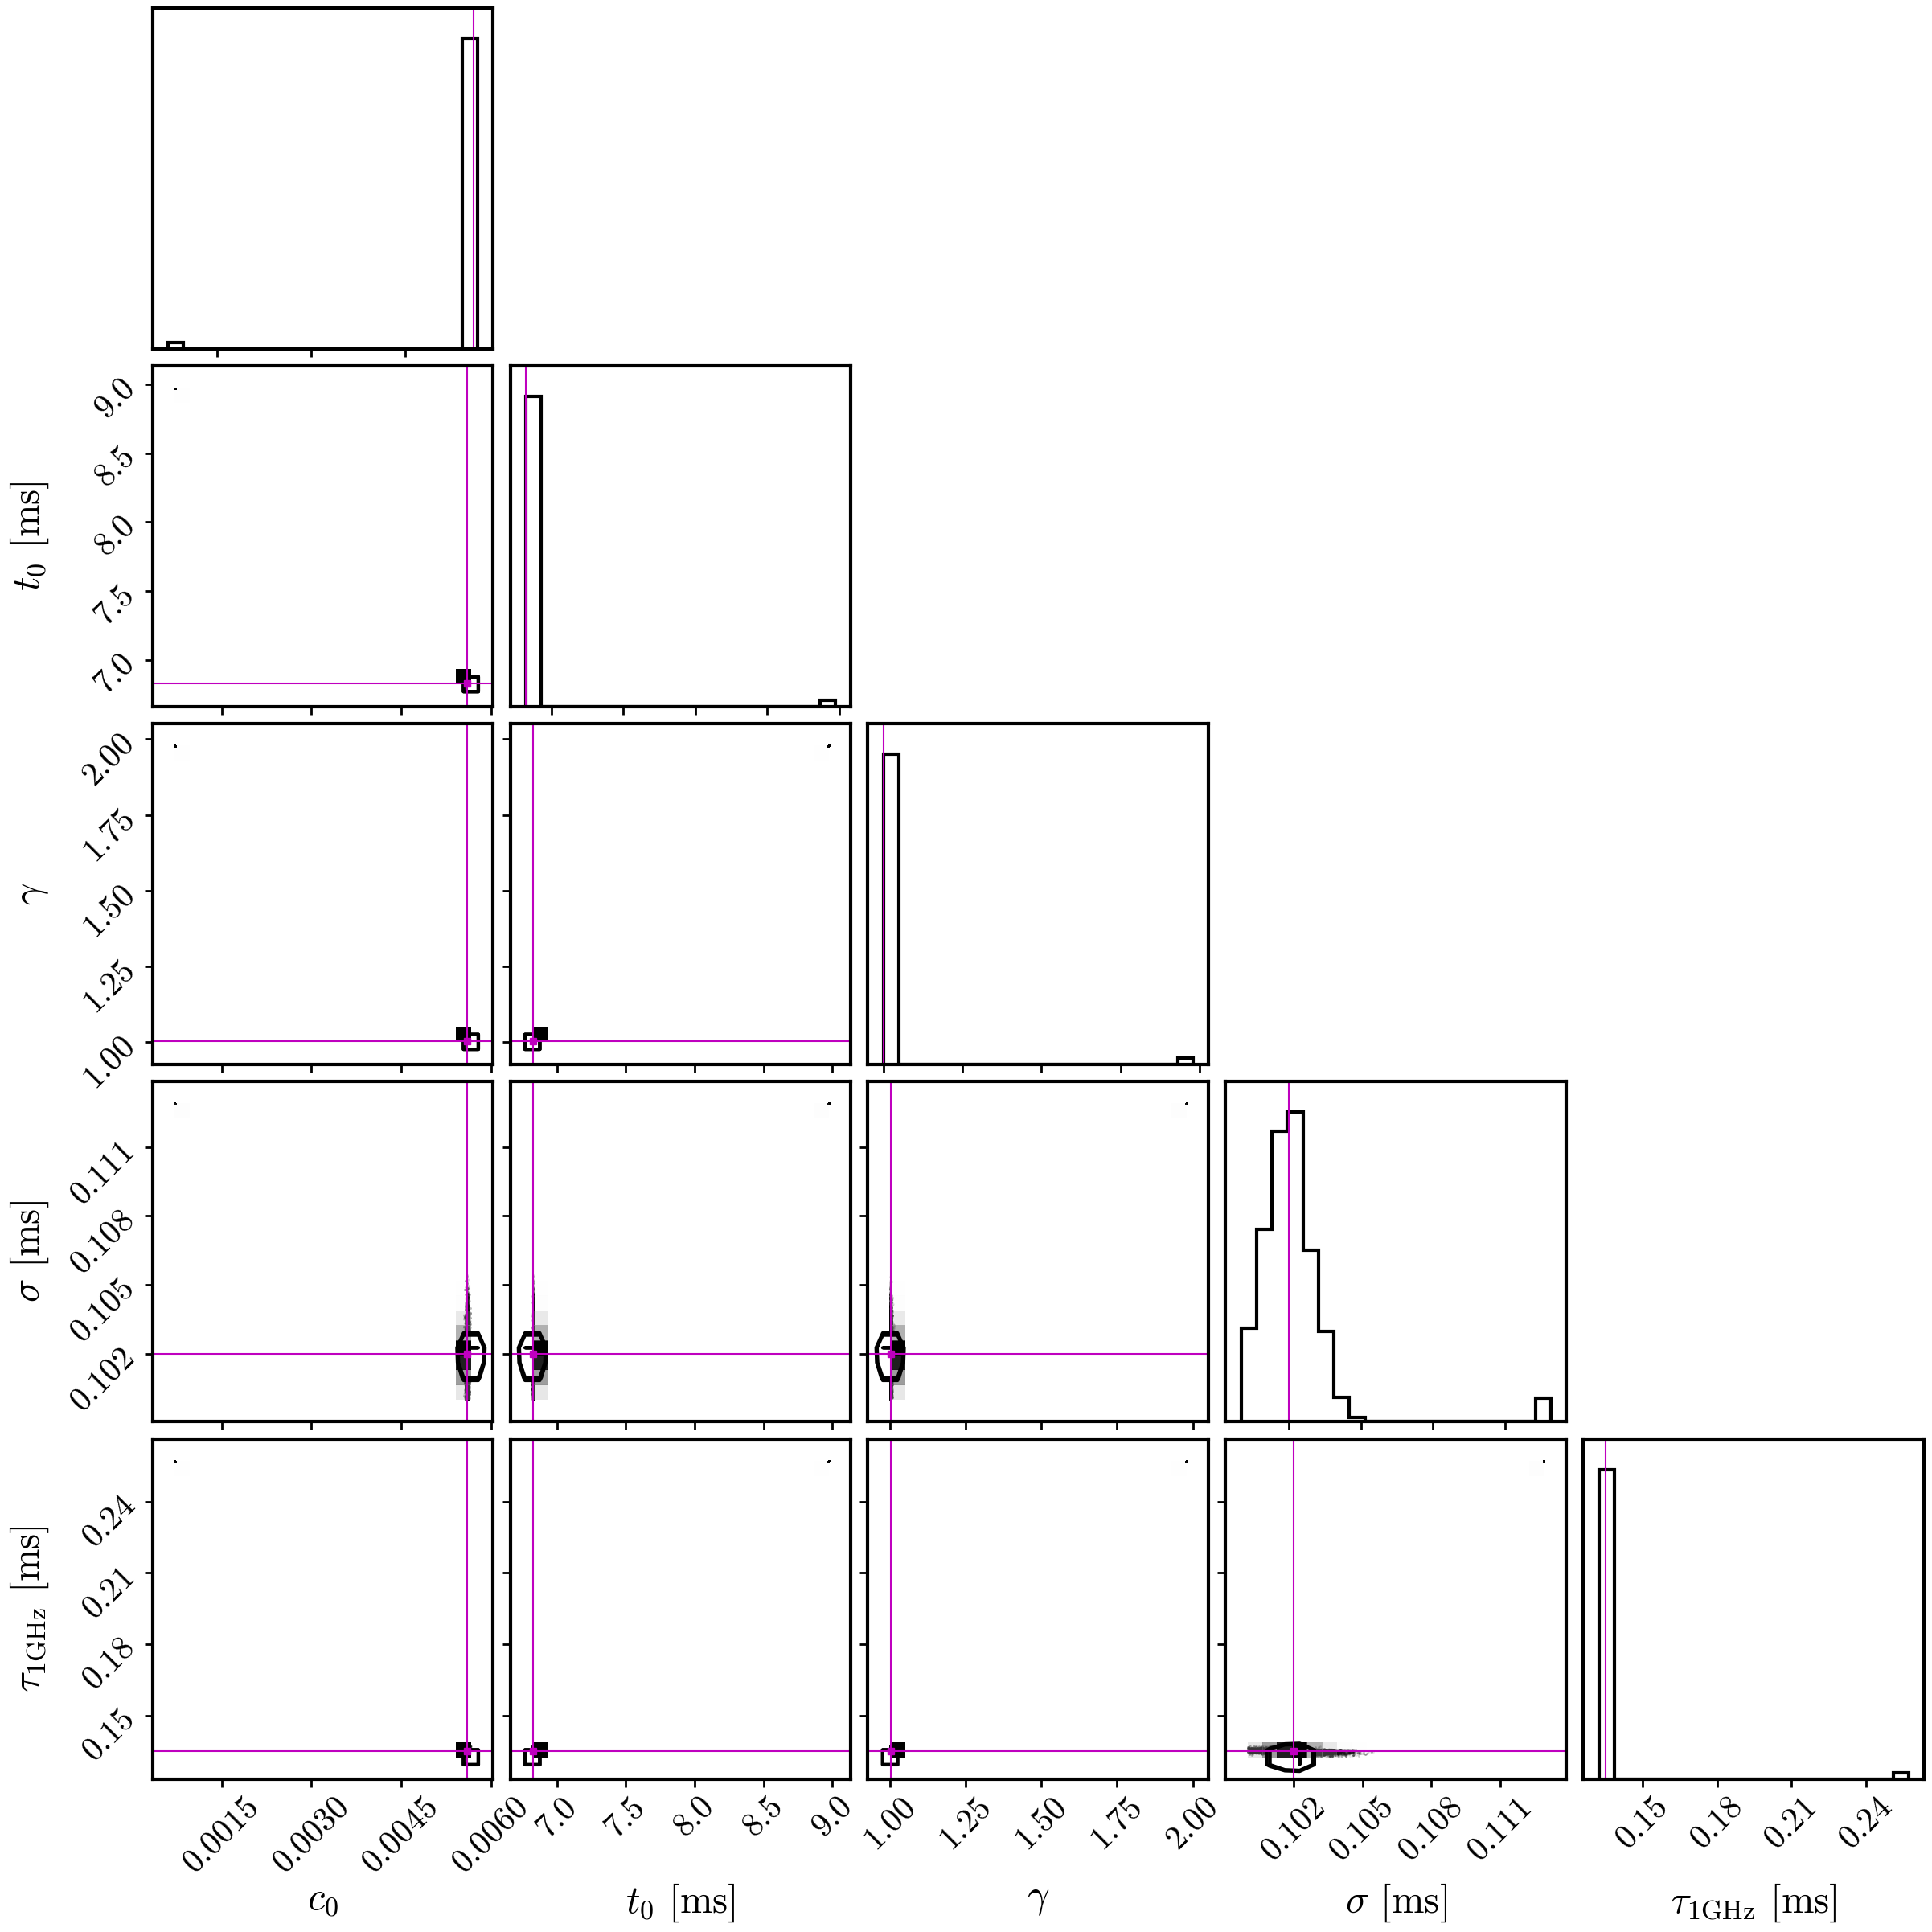

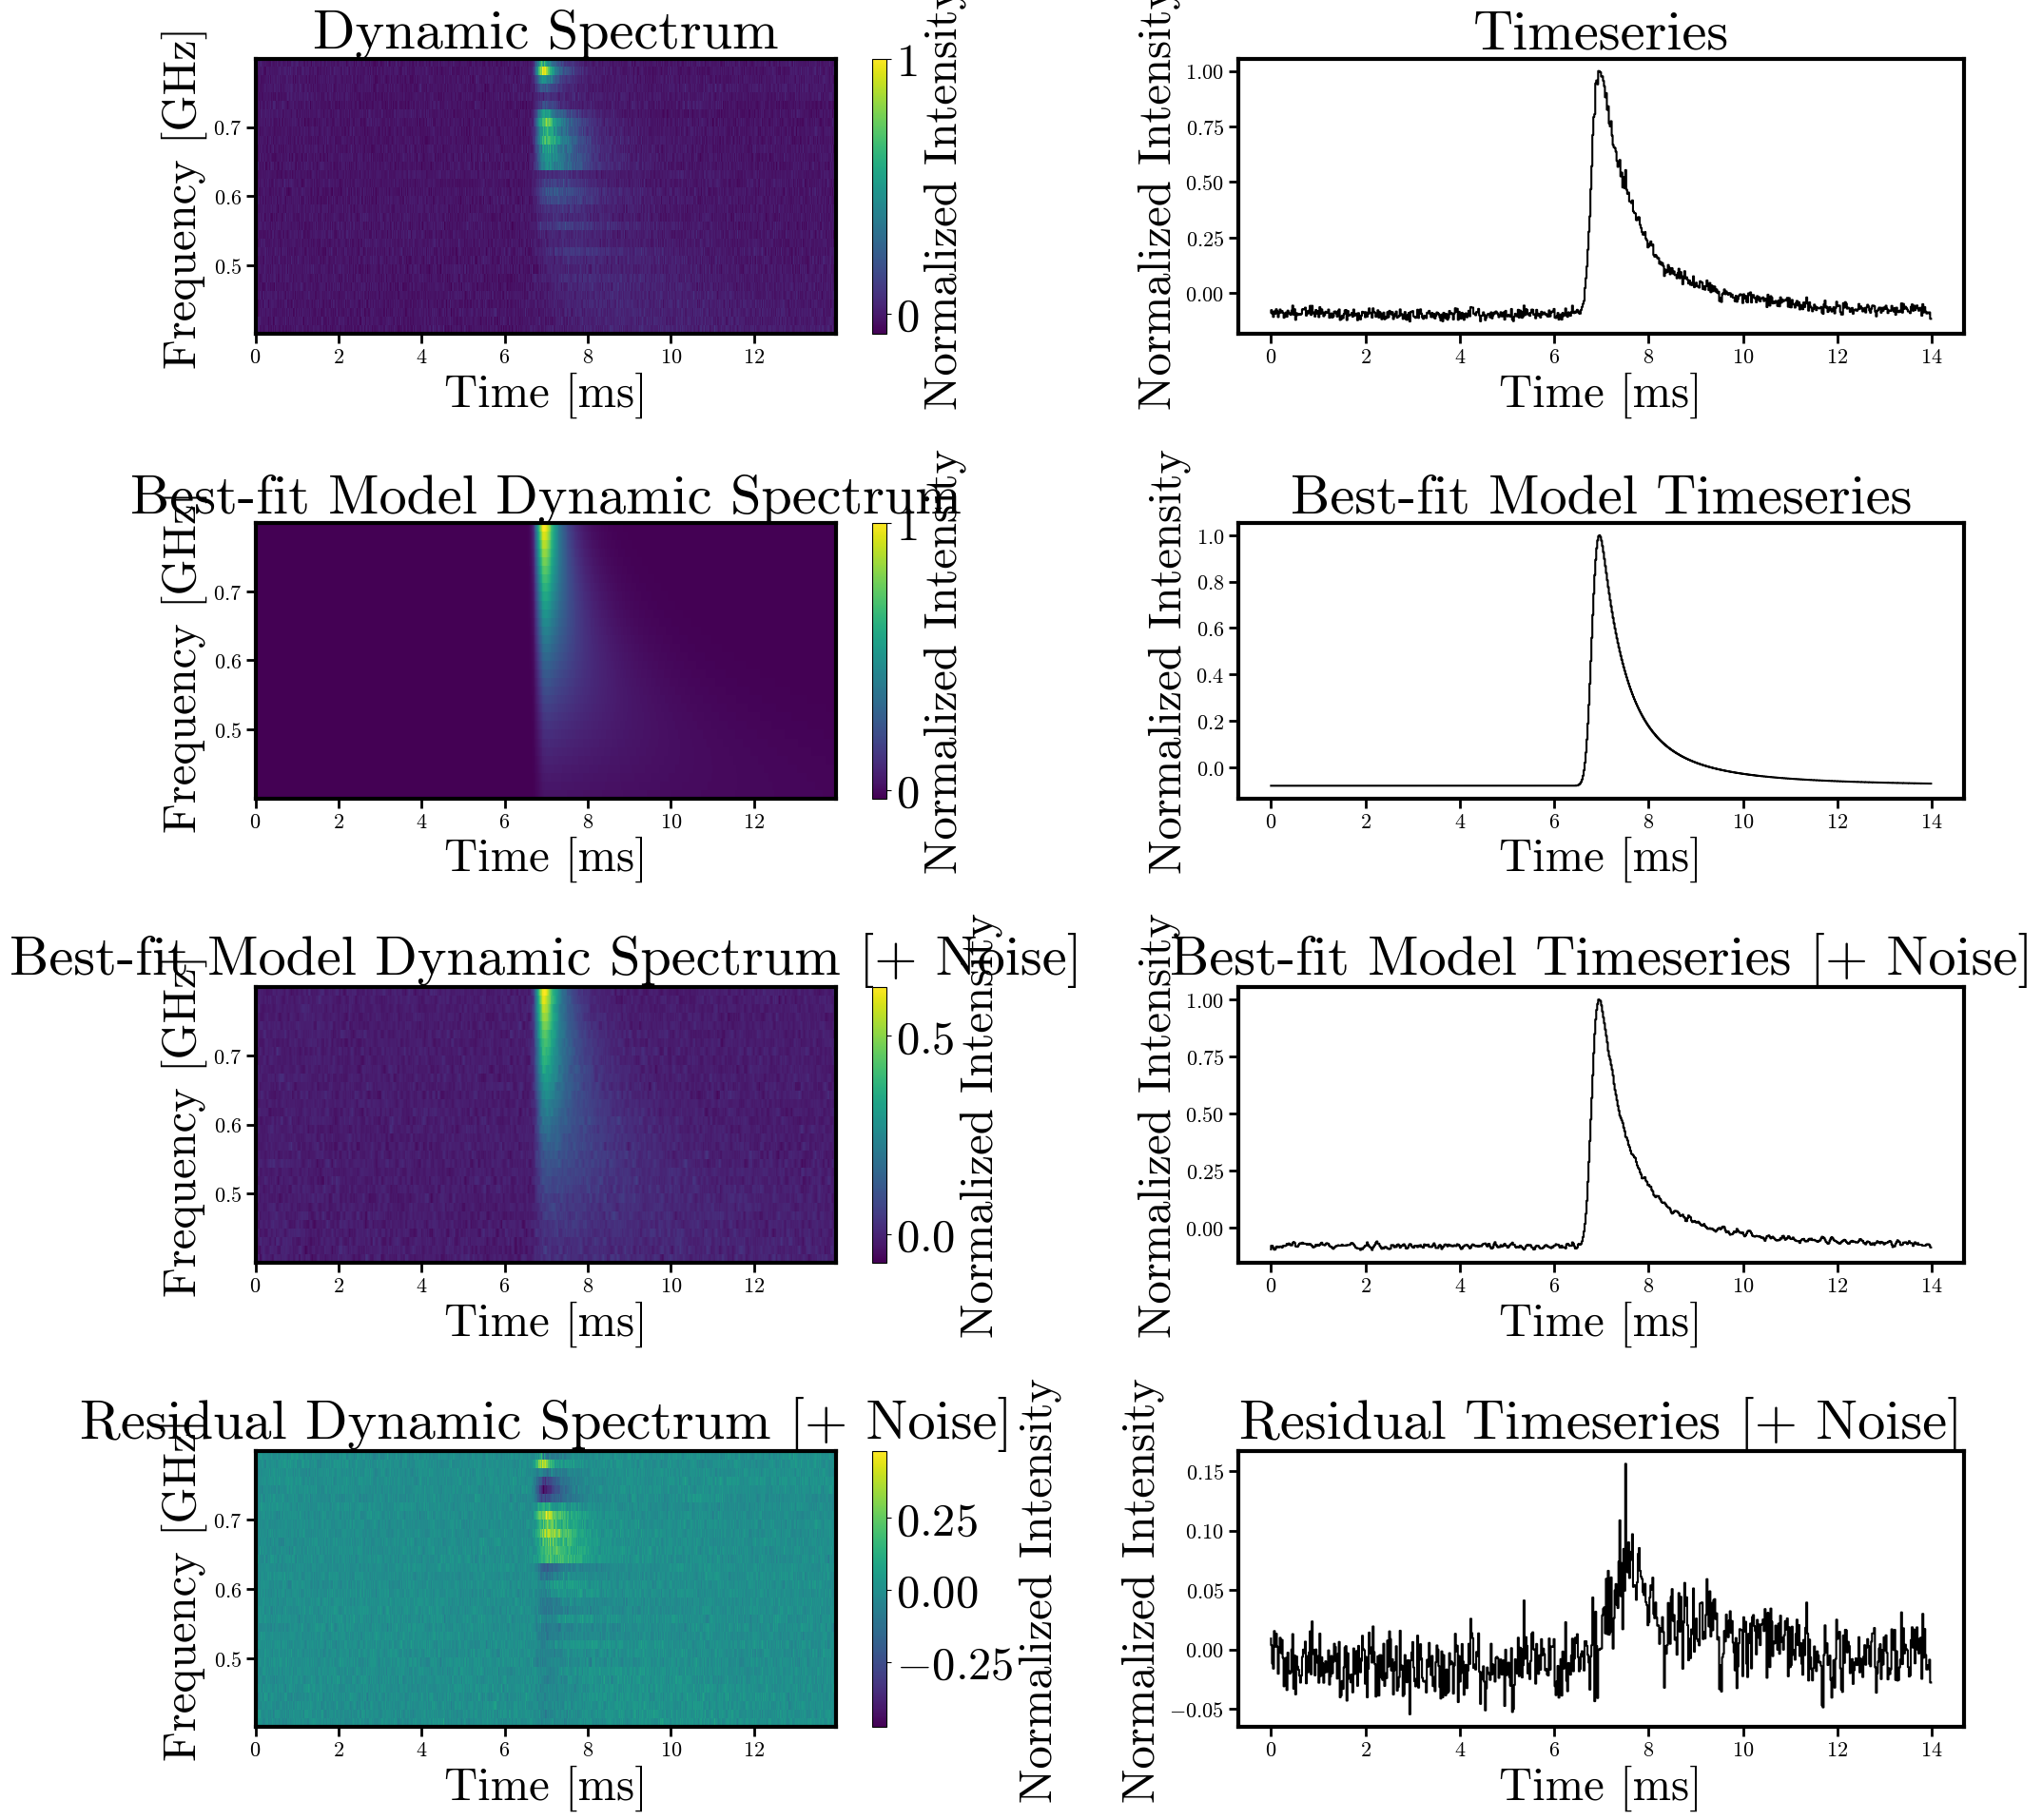

Mean acceptance fraction: 0.45396000000000003


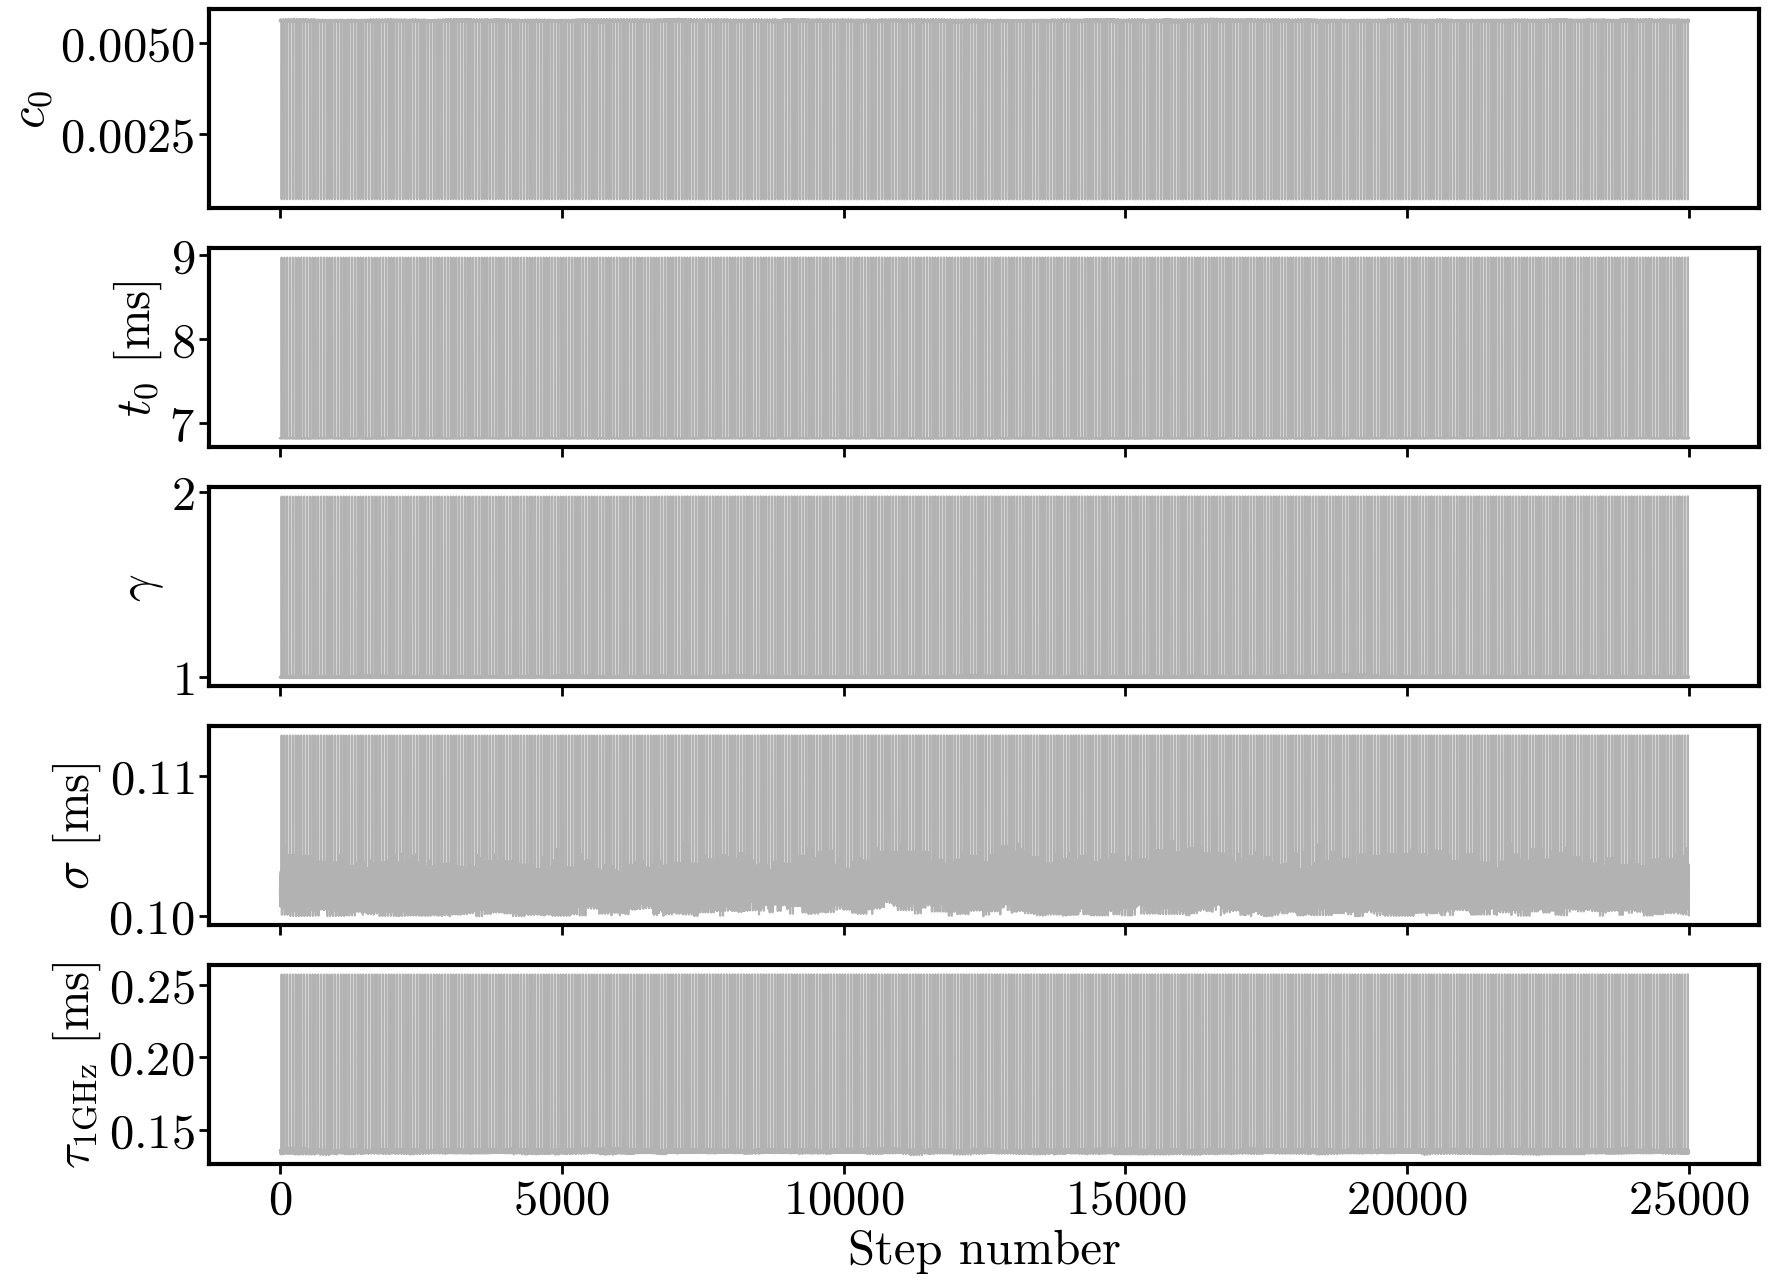

In [34]:
# Plot the data and the best-fit model
#best_fit_index = np.argmax(best_sampler.get_log_prob(discard=burn_in, flat=True))
#best_fit_index = np.argmax(log_prob)
#best_fit_params = samples[best_fit_index]

print(f'Best Fit Params: {best_fit_params}')

rcParams['font.size'] = 35

# Plot the corner plot
# Define figure size before creating the corner plot
fig = plt.figure(figsize=(25, 25))  # Adjust width and height

labels = [r'$c_0$', r'$t_0$ [ms]', r'$\gamma$', r'$\sigma$ [ms]', r'$\tau_\mathrm{1GHz}$ [ms]']

fig = corner.corner(relevant_samples, labels=labels, truths=best_fit_params, fig=fig, truth_color='m', hist_kwargs={'linewidth': 3, 'histtype': 'step'}, contour_kwargs={'linewidths': 3})

for ax in fig.axes:
    # Spine widths
    ax.spines['top'].set_linewidth(3)
    ax.spines['bottom'].set_linewidth(3)
    ax.spines['left'].set_linewidth(3)
    ax.spines['right'].set_linewidth(3)

    # Tick parameters
    ax.tick_params(which='both', width=2)
    ax.tick_params(which='major', length=7)
    ax.tick_params(which='minor', length=5)
    ax.tick_params(which='minor', axis='y', length=5)
    ax.tick_params(axis='both', labelsize=30)

fig.savefig(f'{name}_corner.pdf', bbox_inches = 'tight')
plt.show()

# Compute the model spectrum using the best-fit parameters
best_fit_model = model_instance.model(best_fit_params, model_type=best_model)

# Normalized data
norm_data = model_instance.data - np.mean(model_instance.data)
norm_data = norm_data / np.max(norm_data)

data_timeseries = np.sum(norm_data, axis=0)
norm_data_timeseries = data_timeseries - np.mean(data_timeseries)
norm_data_timeseries = norm_data_timeseries / np.max(norm_data_timeseries)

data_spectrum = np.sum(norm_data, axis=1)
norm_data_spectrum = data_spectrum - np.mean(data_spectrum)
norm_data_spectrum = norm_data_spectrum / np.max(norm_data_spectrum)

# Normalized model
norm_model = best_fit_model - np.mean(best_fit_model)
norm_model = norm_model / np.max(norm_model)

norm_model_timeseries = np.sum(norm_model, axis = 0)
norm_model_timeseries = norm_model_timeseries - np.mean(norm_model_timeseries)
norm_model_timeseries = norm_model_timeseries / np.max(norm_model_timeseries)

norm_model_spectrum = np.sum(norm_model, axis = 1)
norm_model_spectrum = norm_model_spectrum - np.mean(norm_model_spectrum)
norm_model_spectrum = norm_model_spectrum / np.max(norm_model_spectrum)

# Plot the data and the best-fit model separately for comparison
fig = plt.figure(figsize=(20, 20))

for i in range(1, 9):
    plt.subplot(4, 2, i)
    ax = plt.gca()
    
    # Spine widths
    ax.spines['top'].set_linewidth(3)
    ax.spines['bottom'].set_linewidth(3)
    ax.spines['left'].set_linewidth(3)
    ax.spines['right'].set_linewidth(3)

    # Tick parameters
    ax.tick_params(which='both', width=2)
    ax.tick_params(which='major', length=7)
    ax.tick_params(which='minor', length=5)
    ax.tick_params(which='minor', axis='y', length=5)
    ax.tick_params(axis='both', labelsize=16)

# Plot the data
plt.subplot(4, 2, 1)
extent = [time[0], time[-1], freq[0], freq[-1]]
plt.imshow(norm_data, extent=extent, aspect='auto', origin='upper', cmap='viridis', interpolation='nearest')
plt.colorbar(label='Normalized Intensity')
plt.xlabel('Time [ms]')
plt.ylabel('Frequency [GHz]')
plt.title('Dynamic Spectrum')

plt.subplot(4, 2, 2)
plt.step(time, norm_data_timeseries, c='k')
plt.xlabel('Time [ms]')
plt.ylabel('Normalized Intensity')
plt.title('Timeseries')

# Plot the best-fit model
plt.subplot(4, 2, 3)
plt.imshow(norm_model, extent=extent, aspect='auto', origin='upper', cmap='viridis', interpolation='nearest')
#plt.imshow(norm_noisy_model, extent=extent, aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(label='Normalized Intensity')
plt.xlabel('Time [ms]')
plt.ylabel('Frequency [GHz]')
plt.title('Best-fit Model Dynamic Spectrum')

plt.subplot(4, 2, 4)
plt.step(time, norm_model_timeseries, c='k')
#plt.plot(time, norm_noisy_timeseries)
plt.xlabel('Time [ms]')
plt.ylabel('Normalized Intensity')
plt.title('Best-fit Model Timeseries')

# Plot the best-fit model with added noise (based on the original data)
# Generate synthetic noise with the same shape as the model
#noise = np.random.normal(loc=0.0, scale=model_instance.noise_std[:, np.newaxis], size=best_fit_model.shape)
noise_sigma = model_instance.noise_std
#noise = np.random.normal(loc=0.0, scale=noise_sigma[:, np.newaxis], size=best_fit_model.shape)
noise = np.random.lognormal(mean=0.0, sigma=noise_sigma[:, np.newaxis], size=best_fit_model.shape)

# Add the synthetic noise to the fitted model
noisy_model = best_fit_model + savgol_filter(noise, 7, 3)
norm_noisy_model = noisy_model - np.mean(noisy_model)
norm_noise_model = norm_noisy_model / np.max(norm_noisy_model)

# Integrate to get the noisy timeseries
noisy_timeseries = np.nansum(norm_noisy_model, axis = 0)
norm_noisy_timeseries = noisy_timeseries - np.mean(noisy_timeseries)
norm_noisy_timeseries = norm_noisy_timeseries / np.max(norm_noisy_timeseries)
noisy_spectrum = np.nansum(norm_noisy_model, axis = 1)
norm_noisy_spectrum = noisy_spectrum / np.max(noisy_spectrum)

plt.subplot(4, 2, 5)
#plt.imshow(norm_model, extent=extent, aspect='auto', origin='lower', cmap='viridis')
plt.imshow(norm_noisy_model, extent=extent, aspect='auto', origin='upper', cmap='viridis', interpolation='nearest')
plt.colorbar(label='Normalized Intensity')
plt.xlabel('Time [ms]')
plt.ylabel('Frequency [GHz]')
plt.title('Best-fit Model Dynamic Spectrum [+ Noise]')

plt.subplot(4, 2, 6)
#plt.plot(time, norm_model_timeseries)
plt.step(time, norm_noisy_timeseries, c='k')
plt.xlabel('Time [ms]')
plt.ylabel('Normalized Intensity')
plt.title('Best-fit Model Timeseries [+ Noise]')

# Plot the residuals
plt.subplot(4, 2, 7)
plt.imshow(norm_data - norm_noisy_model, extent=extent, aspect='auto', origin='upper', cmap='viridis', interpolation='nearest')
plt.colorbar(label='Normalized Intensity')
plt.xlabel('Time [ms]')
plt.ylabel('Frequency [GHz]')
plt.title('Residual Dynamic Spectrum [+ Noise]')

plt.subplot(4, 2, 8)
plt.step(time, norm_data_timeseries - norm_noisy_timeseries, c='k')
plt.xlabel('Time [ms]')
plt.ylabel('Normalized Intensity')
plt.title('Residual Timeseries [+ Noise]')

plt.tight_layout()

fig.savefig(f'{name}_finalmodel_eightpanel.pdf', bbox_inches = 'tight')

plt.show()

# Check the mean acceptance fraction
print("Mean acceptance fraction:", np.mean(best_sampler.acceptance_fraction))

# Trace plots to assess convergence
ndim = len(labels)
fig, axes = plt.subplots(ndim, figsize=(20, 15), sharex=True)
for i in range(ndim):
    axes[i].plot(samples[:, i], "k", alpha=0.3)
    axes[i].set_ylabel(labels[i])
    # Spine widths
    axes[i].spines['top'].set_linewidth(3)
    axes[i].spines['bottom'].set_linewidth(3)
    axes[i].spines['left'].set_linewidth(3)
    axes[i].spines['right'].set_linewidth(3)

    # Tick parameters
    axes[i].tick_params(which='both', width=2)
    axes[i].tick_params(which='major', length=7)
    axes[i].tick_params(which='minor', length=5)
    axes[i].tick_params(which='minor', axis='y', length=5)
axes[-1].set_xlabel("Step number")

fig.savefig(f'{name}_traces.pdf', bbox_inches = 'tight')

plt.show()


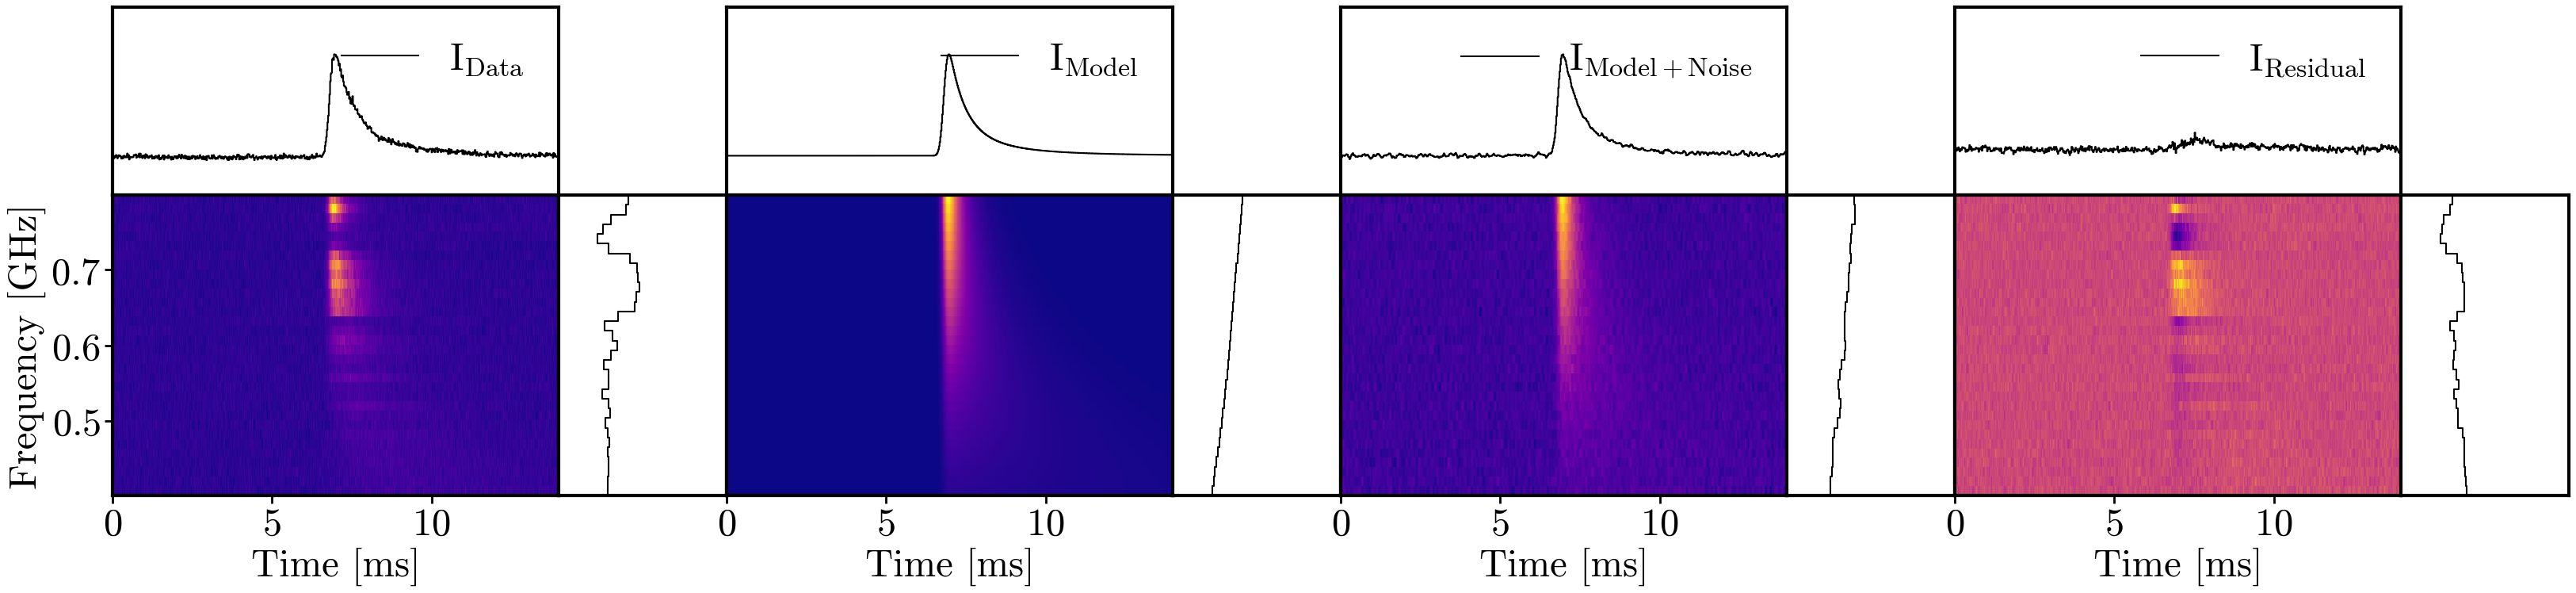

In [33]:
fig, axes = plt.subplots(
    nrows=2, ncols=8, sharex=False, sharey=False,
    gridspec_kw={'height_ratios': [1.25, 2],
                 'width_ratios': [2, 0.75, 2, 0.75, 2, 0.75, 2, 0.75]},
    figsize=(40, 8)
)

rcParams['font.size'] = 40

# Increase border thickness and set tick parameters for every axis
for ax_row in axes:
    for ax in ax_row:
        ax.spines['top'].set_linewidth(3)
        ax.spines['bottom'].set_linewidth(3)
        ax.spines['left'].set_linewidth(3)
        ax.spines['right'].set_linewidth(3)
        ax.tick_params(which='both', width=2)
        ax.tick_params(which='major', length=7)
        ax.tick_params(which='minor', length=5)
        ax.tick_params(which='minor', axis='y', length=5)


extent = [time[0], time[-1], freq[0], freq[-1]]

# ----- PANEL 1: Real Data -----
# Timeseries (top left of panel 1: column 0)
axes[0, 0].step(time, norm_data_timeseries, where='mid', c='k', alpha=1, label='I$_{\mathrm{Data}}$')
axes[0, 0].set_yticks([])
axes[0, 0].set_ylim(-0.5, 1.5)
axes[0, 0].tick_params(axis='x', bottom=False, top=False, labelbottom=False)
axes[0, 0].set_xlim(sim_timesamples[0], sim_timesamples[-1])
axes[0, 0].legend(loc='upper right', fontsize=35, frameon=False)

# Waterfall (bottom left of panel 1: column 0)
axes[1, 0].imshow(norm_data, extent=extent, cmap='plasma', aspect='auto', interpolation='nearest')
axes[1, 0].set_ylabel('Frequency [GHz]')
axes[1, 0].set_xlabel('Time [ms]')

# Spectrum (bottom right of panel 1: column 1)
axes[1, 1].step(np.flip(norm_data_spectrum), freq, where='mid', c='k', alpha=1)
#axes[1, 1].set_xlabel('Intensity')
axes[1, 1].set_xticks([])
axes[1, 1].set_xlim(-2, 4)
axes[1, 1].set_ylim(freq[0], freq[-1])
axes[1, 1].tick_params(axis='y', left=False, right=False, labelleft=False)

# Hide the unused top axis for spectrum (column 1)
axes[0, 1].axis('off')
axes[0, 1].set_visible(False)

# ----- PANEL 2: Simulated Data (Model) -----
# Timeseries (top left of panel 1: column 0)
axes[0, 2].step(time, norm_model_timeseries, where='mid', c='k', alpha=1, label='I$_{\mathrm{Model}}$')
axes[0, 2].set_yticks([])
axes[0, 2].set_ylim(-0.5, 1.5)
axes[0, 2].tick_params(axis='x', bottom=False, top=False, labelbottom=False)
axes[0, 2].set_xlim(time[0], time[-1])
axes[0, 2].legend(loc='upper right', fontsize=35, frameon=False)

# Waterfall (bottom left of panel 1: column 0)
axes[1, 2].imshow(norm_model, extent=extent, cmap='plasma', aspect='auto', interpolation='nearest')
axes[1, 2].set_xlabel('Time [ms]')
axes[1, 2].set_yticks([])

# Spectrum (bottom right of panel 1: column 1)
axes[1, 3].step(np.flip(norm_model_spectrum), freq, where='mid', c='k', alpha=1)
#axes[1, 1].set_xlabel('Intensity')
axes[1, 3].set_xticks([])
axes[1, 3].set_xlim(-4, 8)
axes[1, 3].set_ylim(freq[0], freq[-1])
axes[1, 3].tick_params(axis='y', left=False, right=False, labelleft=False)

# Hide the unused top axis for spectrum (column 1)
axes[0, 3].axis('off')
axes[0, 3].set_visible(False)

# ----- PANEL 3: Simulated Data + Noise -----
# Timeseries (top left of panel 2: column 2)
axes[0, 4].step(time, norm_noisy_timeseries, where='mid', c='k', alpha=1, label='I$_{\mathrm{Model+Noise}}$')
axes[0, 4].set_yticks([])
axes[0, 4].set_ylim(-0.5, 1.5)
axes[0, 4].tick_params(axis='x', bottom=False, top=False, labelbottom=False)
axes[0, 4].set_xlim(time[0], time[-1])
axes[0, 4].legend(loc='upper right', fontsize=35, frameon=False)

# Waterfall (bottom left of panel 2: column 2)
axes[1, 4].imshow(norm_noisy_model, extent=extent, cmap='plasma', aspect='auto', interpolation='nearest')
#axes[1, 2].set_ylabel('Frequency [MHz]')
axes[1, 4].set_yticks([])
axes[1, 4].set_xlabel('Time [ms]')

# Spectrum (bottom right of panel 2: column 3)
axes[1, 5].step(np.flip(norm_noisy_spectrum), freq, where='mid', c='k', alpha=1)
#axes[1, 3].set_xlabel('Intensity')
axes[1, 5].set_xticks([])
axes[1, 5].set_xlim(-4, 8)
axes[1, 5].set_ylim(freq[0], freq[-1])
axes[1, 5].tick_params(axis='y', left=False, right=False, labelleft=False)

# Hide the unused top axis for spectrum (column 3)
axes[0, 5].axis('off')
axes[0, 5].set_visible(False)

# ----- PANEL 4: Residuals -----
# Timeseries residual (top left of panel 3: column 4)
axes[0, 6].step(time, norm_data_timeseries - norm_noisy_timeseries, where='mid', c='k', alpha=1, label='I$_{\mathrm{Residual}}$')
axes[0, 6].set_yticks([])
axes[0, 6].set_ylim(-0.5, 1.5)
axes[0, 6].tick_params(axis='x', bottom=False, top=False, labelbottom=False)
axes[0, 6].set_xlim(time[0], time[-1])
axes[0, 6].legend(loc='upper right', fontsize=35, frameon=False)

# Waterfall residual (bottom left of panel 3: column 4)
axes[1, 6].imshow(norm_data - norm_noisy_model, extent=extent, cmap='plasma', aspect='auto', interpolation='nearest')
#axes[1, 4].set_ylabel('Frequency [MHz]')
axes[1, 6].set_yticks([])
axes[1, 6].set_xlabel('Time [ms]')

# Spectrum for residuals (bottom right of panel 3: column 5)
axes[1, 7].step(np.flip(norm_data_spectrum - norm_noisy_spectrum), freq, where='mid', c='k', alpha=1, label='I$_{\mathrm{norm}}$')
#axes[1, 5].set_xlabel('Intensity')
axes[1, 7].set_xticks([])
axes[1, 7].set_xlim(-4, 8)
axes[1, 7].set_ylim(freq[0], freq[-1])
axes[1, 7].tick_params(axis='y', left=False, right=False, labelleft=False)

# Hide the unused top axis for spectrum (column 5)
axes[0, 7].axis('off')
axes[0, 7].set_visible(False)
plt.subplots_adjust(hspace=0, wspace=0)

fig.savefig(f'{name}_finalmodel_fourpanel.pdf', bbox_inches = 'tight')

plt.show()


In [60]:
# Load data
name = 'freya_278720455'
basepath = '/arc/home/jfaber/baseband_morphologies/CHIME_DSA_Codetections/CHIME_pkl'
pkl_file = f'{name}_fullstokes.pkl'
with open(os.path.join(basepath, pkl_file), 'rb') as file:
    data_pkl = pickle.load(file)  # The file is open only within this block

In [152]:
#%load_ext autoreload
#%autoreload 2
import scint_funcs
importlib.reload(scint_funcs)
import h5py
from scint_funcs import upchannel as upchan
from scint_funcs import make_scallop_model, acf_scint_plot, scrunch, acf_per_subband, weighted_avg_and_std
from scint_funcs import lorentz_withc_min, lorentz_w_c, doublelorentz_withc_min, doublelorentz_w_c,triplelorentz_min, triplelorentz, lorentz, lin, linmin
from scint_funcs import scint_freq_relation, scint_freq_relation_min
from scint_funcs import emission_size, res

import os

import pickle

import matplotlib 
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

from lmfit import minimize, Parameters, fit_report, Model, Minimizer, report_fit

import matplotlib.gridspec as gridspec

import scipy.constants as cons

(27000.0, 37000.0)

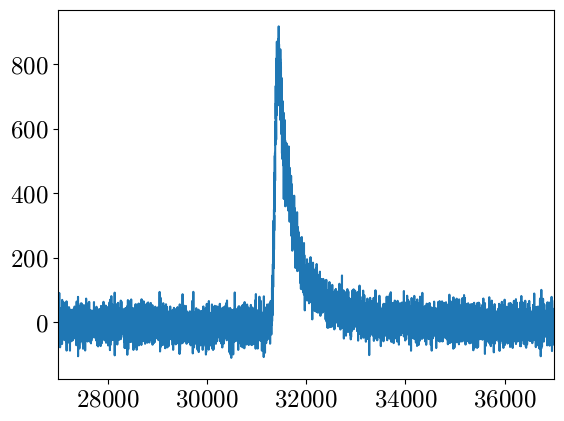

In [153]:
plt.plot(data_pkl["I"][:, :].sum(0))
plt.xlim(27000, 37000)

In [154]:
I_on = data_pkl["I"][:, 27000:37000]
Q_on = data_pkl["Q"][:, 27000:37000]
U_on = data_pkl["U"][:, 27000:37000]
V_on = data_pkl["V"][:, 27000:37000]

data = np.stack((I_on, Q_on, U_on, V_on), axis=0)
data = np.swapaxes(data, 1, 2)
print(data.shape)

I_off = data_pkl["I"][:, 17000:27000]
Q_off = data_pkl["Q"][:, 17000:27000]
U_off = data_pkl["U"][:, 17000:27000]
V_off = data_pkl["V"][:, 17000:27000]

data_off = np.stack((I_off, Q_off, U_off, V_off), axis=0)
data_off = np.swapaxes(data_off, 1, 2)
print(data_off.shape)

freq = np.linspace(400.1953125, 800.1953125, 1024)
freqid = np.arange(1024)
print(freq.shape)
print(freqid.shape)

(4, 10000, 1024)
(4, 10000, 1024)
(1024,)
(1024,)


In [155]:
fftsize=16
downfreq=1
data_dedisp_masked_upchan_ds = upchan(data,freqid,fftsize=fftsize,downfreq=downfreq)

In [156]:
print(data_dedisp_masked_upchan_ds[0].shape)

(4, 625, 16384)


In [157]:
fftsize=16
downfreq=1
#data_dedisp_masked_upchan_ds = upchan(data,freqid,fftsize=fftsize,downfreq=downfreq)
#upchannel the noise to model the scalloping
noise_dedisp_masked_upchan_ds = upchan(data_off,freqid,fftsize=fftsize,downfreq=downfreq)

model_ds, inds = make_scallop_model(noise_dedisp_masked_upchan_ds[0], fftsize, downfreq)

In [158]:
print(data_dedisp_masked_upchan_ds[0].shape)

(4, 625, 16384)


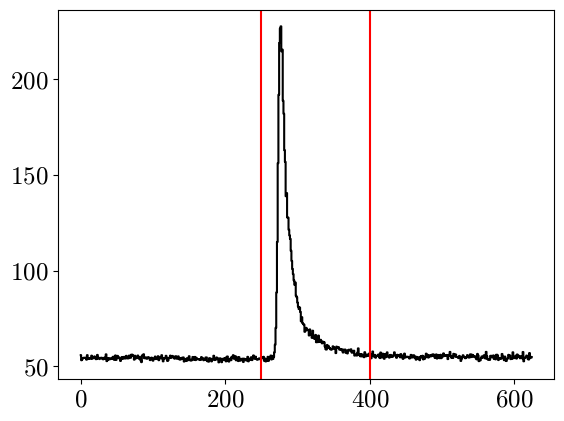

In [159]:
power = np.abs(data_dedisp_masked_upchan_ds[0]**2)
I_upchan_ds = np.sum(power,axis=0).T

#beginning and end index of the burst
beginburst= 250
endburst = 400

plt.plot(np.nanmean(I_upchan_ds,axis=0), drawstyle='steps-mid',color='k')
plt.axvline(beginburst,color='r')
plt.axvline(endburst,color='r')
#plt.xlim(400, 650)
plt.show()

In [160]:
#per channel remove the scalloping
#also normalise using the off burst data

#off burst time range in bins
offburst_begin=0
offburst_end=200

I_upchan_corrected = np.zeros_like(I_upchan_ds)
for time_bin in range(I_upchan_ds.shape[1]):
    I_upchan_corrected[:,time_bin] = I_upchan_ds[:,time_bin]/model_ds
    
    
for freq_chan in range(I_upchan_corrected.shape[0]):
    Ioff=I_upchan_corrected[freq_chan,offburst_begin:offburst_end]
    I_upchan_corrected[freq_chan,:] = I_upchan_corrected[freq_chan,:] - np.nanmean(Ioff)
    Ioff-=np.nanmean(Ioff)
    I_upchan_corrected[freq_chan,:] = I_upchan_corrected[freq_chan,:] / np.nanstd(Ioff)
    
    
prof = np.nansum(I_upchan_corrected, axis = 0)
offprof = prof[0:200]
prof -= np.nanmean(offprof)
prof /= np.nanstd(offprof)

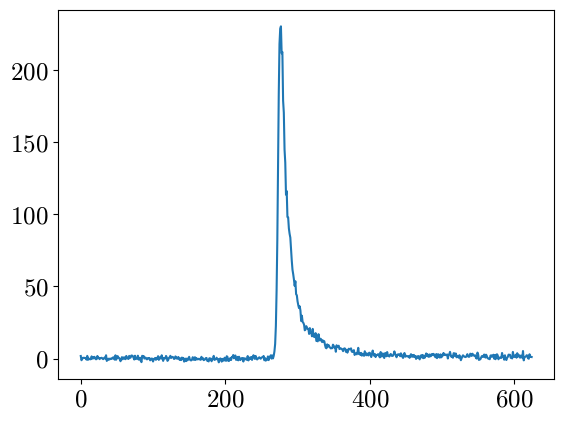

(16384, 625)


In [167]:
plt.plot(prof)
plt.show()
print(I_upchan_corrected.shape)

/tmp/ipykernel_369/1053023256.py:17: RuntimeWarning: Mean of empty slice
  spec_upchan = np.nanmean(I_upchan_corrected[:14000,i-1:i+1],axis=1)
/tmp/ipykernel_369/1053023256.py:20: RuntimeWarning: Mean of empty slice
  spec_fake = np.nanmean(I_upchan_corrected[:14000,0:20],axis=1)


Frequency resolution is 0.02442 MHz


100%|██████████| 163/163 [00:00<00:00, 7223.15it/s]

Could not fit a Lorentzian
err 0.07856742013183861
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 89
    # data points      = 244
    # variables        = 3
    chi-square         = 52.4993899
    reduced chi-square = 0.21783979
    Akaike info crit   = -368.873469
    Bayesian info crit = -358.381965
[[Variables]]
    gamma1:  0.37501315 +/- 0.20628503 (55.01%) (init = 0.2)
    m1:      0.59594238 +/- 0.06996280 (11.74%) (init = 1)
    c:       1.58066476 +/- 0.05580555 (3.53%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(gamma1, c)  = -0.6126
    C(m1, c)      = -0.4934
    C(gamma1, m1) = -0.1091
None


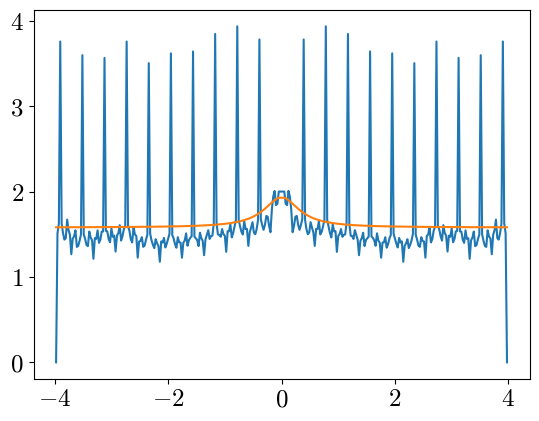

Frequency resolution is 0.02442 MHz


100%|██████████| 163/163 [00:00<00:00, 6102.09it/s]


Could not fit a Lorentzian
err 0.07856742013183861
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 49
    # data points      = 244
    # variables        = 3
    chi-square         = 77.2803896
    reduced chi-square = 0.32066552
    Akaike info crit   = -274.533631
    Bayesian info crit = -264.042126
[[Variables]]
    gamma1:  0.12327778 +/- 0.12632764 (102.47%) (init = 0.2)
    m1:      0.57175479 +/- 0.15446405 (27.02%) (init = 1)
    c:       1.64639139 +/- 0.05021868 (3.05%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(gamma1, m1) = -0.7096
    C(gamma1, c)  = -0.4335
None


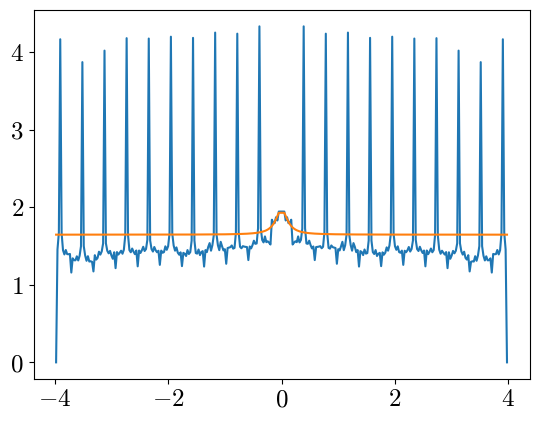

Frequency resolution is 0.02442 MHz


100%|██████████| 163/163 [00:00<00:00, 7540.22it/s]

Could not fit a Lorentzian
err 0.07856742013183861
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 49
    # data points      = 244
    # variables        = 3
    chi-square         = 59.9854922
    reduced chi-square = 0.24890246
    Akaike info crit   = -336.347979
    Bayesian info crit = -325.856475
[[Variables]]
    gamma1:  0.14744314 +/- 0.10265954 (69.63%) (init = 0.2)
    m1:      0.59907148 +/- 0.10651522 (17.78%) (init = 1)
    c:       1.33352643 +/- 0.04150021 (3.11%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(gamma1, m1) = -0.6314
    C(gamma1, c)  = -0.4523
    C(m1, c)      = -0.1057
None


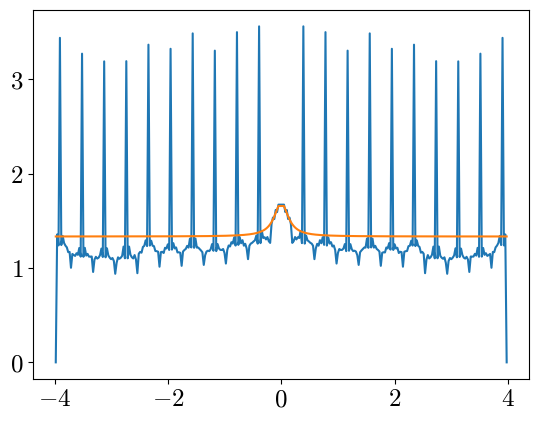

Frequency resolution is 0.02442 MHz


100%|██████████| 163/163 [00:00<00:00, 7804.11it/s]

Could not fit a Lorentzian
err 0.07856742013183861
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 81
    # data points      = 244
    # variables        = 3
    chi-square         = 47.4232750
    reduced chi-square = 0.19677707
    Akaike info crit   = -393.685440
    Bayesian info crit = -383.193935
[[Variables]]
    gamma1:  0.35776628 +/- 0.17988585 (50.28%) (init = 0.2)
    m1:      0.58014625 +/- 0.06390409 (11.02%) (init = 1)
    c:       1.21113952 +/- 0.04606070 (3.80%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(gamma1, c)  = -0.6009
    C(m1, c)      = -0.4325
    C(gamma1, m1) = -0.1895
None


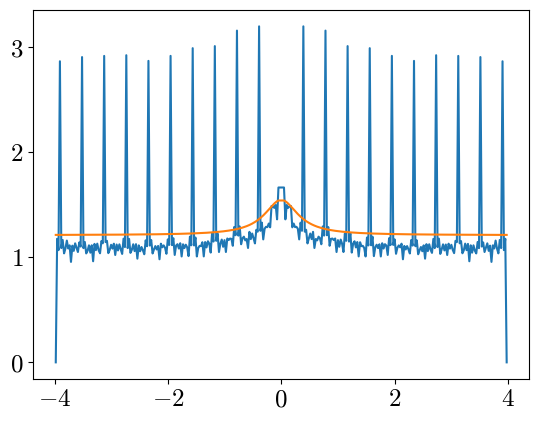

Frequency resolution is 0.02442 MHz


100%|██████████| 163/163 [00:00<00:00, 6975.88it/s]

Could not fit a Lorentzian
err 0.07856742013183861
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 25
    # data points      = 244
    # variables        = 3
    chi-square         = 32.6711157
    reduced chi-square = 0.13556480
    Akaike info crit   = -484.605151
    Bayesian info crit = -474.113647
[[Variables]]
    gamma1:  0.17351284 +/- 0.07837055 (45.17%) (init = 0.2)
    m1:      0.59717761 +/- 0.06786594 (11.36%) (init = 1)
    c:       1.09188159 +/- 0.02852481 (2.61%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(gamma1, m1) = -0.5754
    C(gamma1, c)  = -0.4703
    C(m1, c)      = -0.1424
None


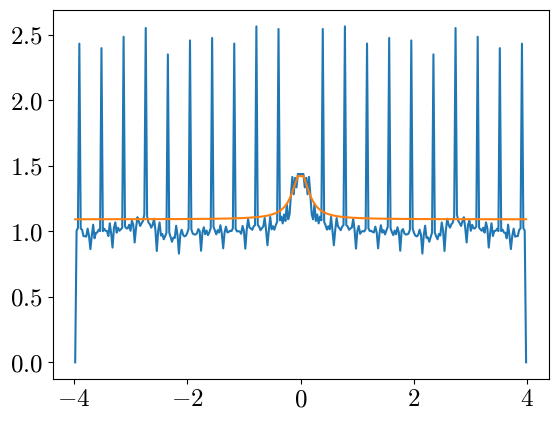

Frequency resolution is 0.02442 MHz


100%|██████████| 163/163 [00:00<00:00, 7793.97it/s]

Could not fit a Lorentzian
err 0.07856742013183861


[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 21
    # data points      = 244
    # variables        = 3
    chi-square         = 23.1528337
    reduced chi-square = 0.09606985
    Akaike info crit   = -568.632455
    Bayesian info crit = -558.140950
[[Variables]]
    gamma1:  0.11865008 +/- 0.04074104 (34.34%) (init = 0.2)
    m1:      0.67643119 +/- 0.07006162 (10.36%) (init = 1)
    c:       0.86261017 +/- 0.02000098 (2.32%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(gamma1, m1) = -0.7618
    C(gamma1, c)  = -0.4158
None


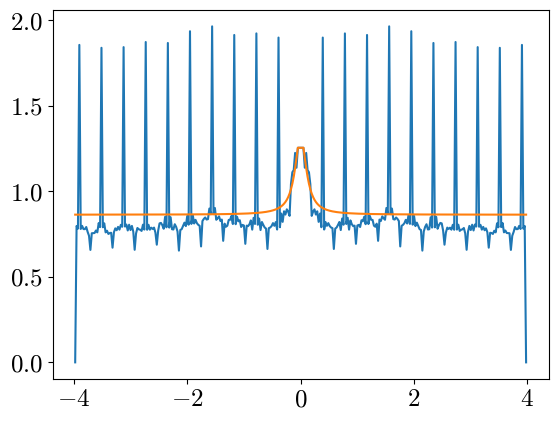

Frequency resolution is 0.02442 MHz


100%|██████████| 163/163 [00:00<00:00, 7716.21it/s]

Could not fit a Lorentzian
err 0.07856742013183861
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 21
    # data points      = 244
    # variables        = 3
    chi-square         = 16.1000705
    reduced chi-square = 0.06680527
    Akaike info crit   = -657.276076
    Bayesian info crit = -646.784571
[[Variables]]
    gamma1:  0.18834463 +/- 0.05237273 (27.81%) (init = 0.2)
    m1:      0.61487576 +/- 0.04300417 (6.99%) (init = 1)
    c:       0.93994942 +/- 0.01903836 (2.03%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(gamma1, m1) = -0.5539
    C(gamma1, c)  = -0.4814
    C(m1, c)      = -0.1523
None


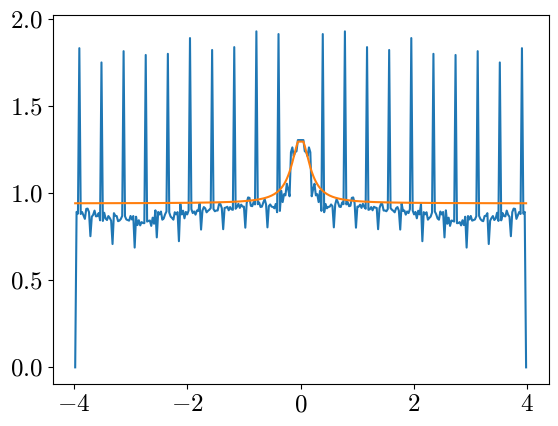

Frequency resolution is 0.02442 MHz


100%|██████████| 163/163 [00:00<00:00, 6755.98it/s]

Could not fit a Lorentzian
err 0.07856742013183861
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 21
    # data points      = 244
    # variables        = 3
    chi-square         = 14.2516545
    reduced chi-square = 0.05913550
    Akaike info crit   = -687.032033
    Bayesian info crit = -676.540528
[[Variables]]
    gamma1:  0.15093723 +/- 0.03132362 (20.75%) (init = 0.2)
    m1:      0.71096901 +/- 0.04078524 (5.74%) (init = 1)
    c:       0.77407288 +/- 0.01567136 (2.02%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(gamma1, m1) = -0.6677
    C(gamma1, c)  = -0.4417
None


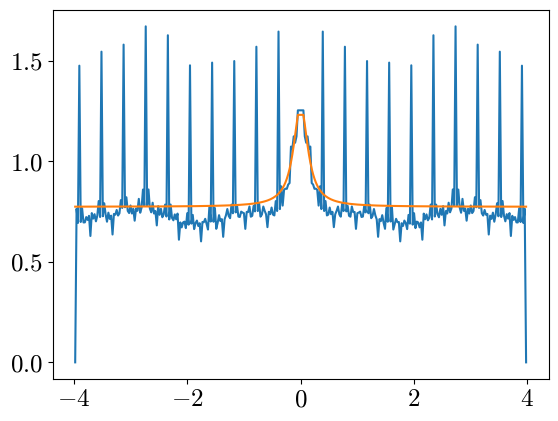

Frequency resolution is 0.02442 MHz


100%|██████████| 163/163 [00:00<00:00, 7015.83it/s]

Could not fit a Lorentzian
err 0.07856742013183861
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 41
    # data points      = 244
    # variables        = 3
    chi-square         = 11.2741021
    reduced chi-square = 0.04678051
    Akaike info crit   = -744.217035
    Bayesian info crit = -733.725530
[[Variables]]
    gamma1:  0.18688966 +/- 0.03185983 (17.05%) (init = 0.2)
    m1:      0.71504586 +/- 0.03104955 (4.34%) (init = 1)
    c:       0.83604671 +/- 0.01521887 (1.82%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(gamma1, m1) = -0.5668
    C(gamma1, c)  = -0.4751
    C(m1, c)      = -0.1369
None


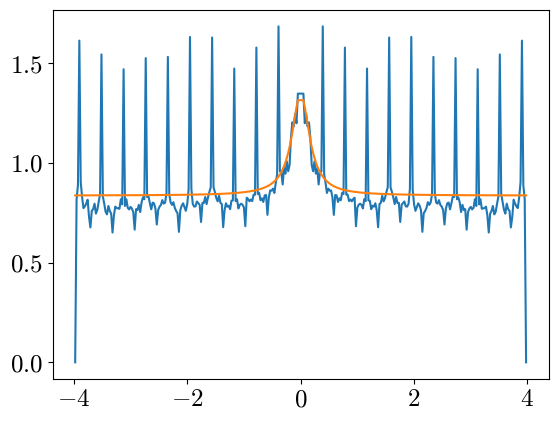

Frequency resolution is 0.02442 MHz


100%|██████████| 163/163 [00:00<00:00, 7588.17it/s]

Could not fit a Lorentzian
err 0.07856742013183861
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 17
    # data points      = 244
    # variables        = 3
    chi-square         = 8.71184875
    reduced chi-square = 0.03614875
    Akaike info crit   = -807.126145
    Bayesian info crit = -796.634640
[[Variables]]
    gamma1:  0.15203281 +/- 0.02052551 (13.50%) (init = 0.2)
    m1:      0.78015710 +/- 0.02893953 (3.71%) (init = 1)
    c:       0.72744945 +/- 0.01207010 (1.66%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(gamma1, m1) = -0.6656
    C(gamma1, c)  = -0.4415
None


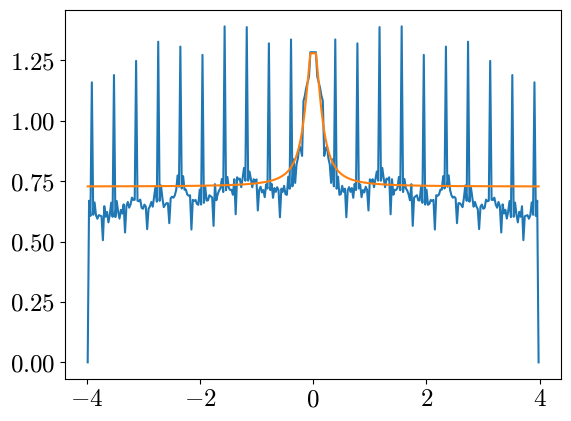

In [168]:
mods=[]
mods_uncert=[]
freq_scale_1=[]
freq_scale_1_uncert=[]
mods_alternative = []
mods_alternative_uncert = []

prof_sn = np.nanmean(I_upchan_corrected,axis=0)
prof_off = prof_sn[:200]
prof_sn -=np.nanmean(prof_off)
prof_off = prof_sn[:200]
prof_sn/=np.nanstd(prof_off)


for i in range(250, 400,2):
    if prof_sn[i-1] > 64:
        spec_upchan = np.nanmean(I_upchan_corrected[:14000,i-1:i+1],axis=1)
        spec_upchan[np.isnan(spec_upchan)]=0
        spec_upchan=np.ma.masked_where(spec_upchan==0,spec_upchan)
        spec_fake = np.nanmean(I_upchan_corrected[:14000,0:20],axis=1)
        spec_fake[np.isnan(spec_fake)]=0
        spec_fake=np.ma.masked_where(spec_fake==0,spec_fake)
    
        acf_res = acf_scint_plot(spec_upchan,data_dedisp_masked_upchan_ds[2],data_dedisp_masked_upchan_ds[1],[0,0],lagrange_for_fit=0.01,diagnostic_plots=False,maxlag=4,offspec_mean=np.nanmean(spec_fake))
        plt.close()
    
        
        lagrange_for_fit=3
        f_res=0.39101/(fftsize//downfreq)

        acf=acf_res[0]
        lag=acf_res[1]
        acf_fit=acf[int(len(acf)/2.)-int(lagrange_for_fit/f_res):int(len(acf)/2.)+int(lagrange_for_fit/f_res)]
        lag_fit=lag[int(len(acf)/2.)-int(lagrange_for_fit/f_res):int(len(acf)/2.)+int(lagrange_for_fit/f_res)]
    
        #compute the ACF correlated errors
        acf_half = acf[len(acf)//2:]
        var_f = np.ones(len(acf_half)) / (len(acf_half))
        var_f[1:] *= 1 + 2 * np.cumsum(acf_half[0:-1] ** 2)
        f_errors = np.sqrt(var_f)
        print("err",f_errors[0])
    
        f_errors_full = np.concatenate((f_errors[::-1],f_errors))
        acf_fit_errors=f_errors_full[int(len(acf)/2.)-int(lagrange_for_fit/f_res):int(len(acf)/2.)+int(lagrange_for_fit/f_res)]
    
        params = Parameters()
        params.add('gamma1', value = 0.2, min= 0.00001, max = 100)
        params.add('m1', value = 1, min = -100, max = 100)
        params.add('c',value=0,min=-100,max=100)
    
        fit = Minimizer(lorentz_withc_min, params, fcn_args=(lag_fit,acf_fit,np.sqrt(acf_fit_errors)))
        result_acf = fit.minimize()
        print(report_fit(result_acf))
    
        plt.plot(lag,acf)
        plt.plot(lag,lorentz_w_c(lag,result_acf.params['gamma1'],result_acf.params['m1'],result_acf.params['c']))
        plt.show()         
    

        mods.append(result_acf.params['m1'].value)
        mods_uncert.append(result_acf.params['m1'].stderr)
        freq_scale_1.append(result_acf.params['gamma1'])
        freq_scale_1_uncert.append(result_acf.params['gamma1'].stderr)
        mods_alternative.append(np.sqrt(np.max(acf_fit)-result_acf.params['c']))
        mods_alternative_uncert.append(np.sqrt(np.max(acf_fit)-result_acf.params['c']) * np.sqrt((f_errors[0]/np.max(acf_fit))**2 + (result_acf.params['c'].stderr/result_acf.params['c'])**2)/2.)
            
    else:
        mods.append(0)
        mods_uncert.append(0)
        freq_scale_1.append(0)
        freq_scale_1_uncert.append(0)
        mods_alternative.append(0)
        mods_alternative_uncert.append(0)
   


In [169]:
mods = np.array(mods)
time_ = np.array(time)
mods_alternative = np.array(mods_alternative)
mods_uncert = np.array(mods_uncert)
mods_alternative_uncert = np.array(mods_alternative_uncert)


In [170]:
print(len(mods))

75


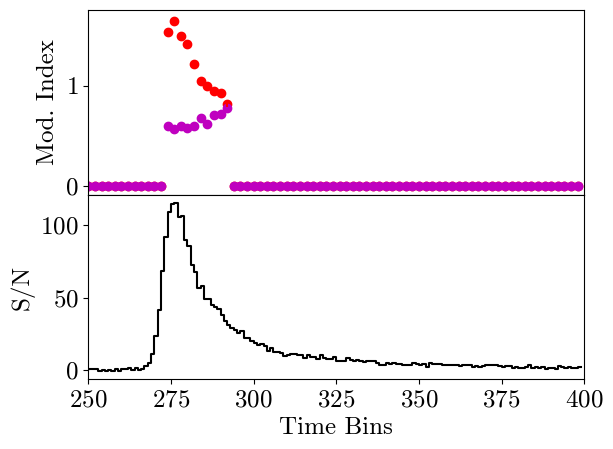

In [172]:
import matplotlib.pyplot as plt

rcParams['font.size'] = 18

# Create two subplots that share the x-axis and have no vertical spacing
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, sharex=True, gridspec_kw={'hspace': 0}
)

# Plot some example data
ax_top.scatter(time_[:], mods_alternative[:], c='r')
ax_top.scatter(time_[:], mods[:], c='m')
ax_top.errorbar(time_[:], mods_alternative[:], yerr = mods_alternative_uncert[:], c='r', fmt='none')
ax_top.set_ylabel('Mod. Index')
ax_bottom.step(time_prof, prof[250:400]/2, drawstyle='steps-mid',color='k')
ax_bottom.set_ylabel('S/N')
ax_bottom.set_xlabel('Time Bins')

# Remove the bottom spine of the top plot and the top spine of the bottom plot for a flush look
ax_top.spines['bottom'].set_visible(True)
ax_bottom.spines['top'].set_visible(True)

# Optionally, remove x-axis tick labels from the top plot
ax_top.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
plt.xlim(250, 400)

# Display the plot
plt.show()


In [122]:
rcParams['font.size'] = 10
for i in np.arange(0, 3):
    #spec_norm = spectrum / np.max(spectrum)
    intensity_tshape = intensity_scint.shape[1]
    intensity_off = intensity_scint[i:i+256, 0:1500]
    offspec_mean = np.nanmean(intensity_off)
    outer_bound = 5
    #spectrum_lim = np.nansum(intensity[i:i+256, intensity_tshape//2 - outer_bound:intensity_tshape//2 + outer_bound], axis=1)
    spectrum_lim = np.nansum(intensity_scint[i:i+256, 2000:3500], axis=1)

    fig = plt.figure()
    #plt.plot(np.nansum(intensity[i:i+256, intensity_tshape//2 - outer_bound:intensity_tshape//2 + outer_bound], axis=0))
    plt.plot(np.nansum(intensity_scint[i:i+256, 2000:3500], axis=0))
    plt.title('Diagnostic: Limited Timeseries')
    plt.show()

    spec_norm = spectrum_lim #/ np.max(spectrum_lim)
    acf=sct.autocorr(spec_norm, offspec_mean = offspec_mean)
    lags=np.arange(len(acf))+1
    acf=acf[1:]
    lags=lags[1:]
    acf=np.concatenate((acf[::-1],acf))
    lags=np.concatenate((-1*lags[::-1],lags))*fres_kHz

    lag_range_for_fit=500 #somewhat arbitrary, 2000 works well to successfully fit the central peak

    gmodel = Model(sct.lorentz)
    acf_for_fit = acf[int(len(acf)/2.)-int(lag_range_for_fit/fres_kHz):int(len(acf)/2.)+int(lag_range_for_fit/fres_kHz)]
    lags_for_fit = lags[int(len(acf)/2.)-int(lag_range_for_fit/fres_kHz):int(len(acf)/2.)+int(lag_range_for_fit/fres_kHz)]
    #result = gmodel.fit(acf_for_fit, x=lags_for_fit, gamma1=10, m1=1,gamma2=100,m2=1, c=0)
    result = gmodel.fit(acf_for_fit, x=lags_for_fit, gamma1=1, m1=1,c=0)
    print(result.fit_report())

    fig = plt.figure(figsize = (8, 5))

    ax = plt.gca()
    ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.xaxis.get_major_formatter().set_scientific(True)
    ax.xaxis.get_major_formatter().set_powerlimits((-4, 4))

    label_str = r'$\mathcal{L}(\Delta \nu =$ ' + str(round(result.params['gamma1'].value)) + r' $\pm$ ' + str(round(result.params['gamma1'].stderr)) + ' kHz)'


    plt.step(lags, acf, c = 'k')
    plt.plot(lags, sct.lorentz(lags, result.params['gamma1'], result.params['m1'], result.params['c']), c = 'm', lw = 3, label = label_str)
    plt.plot(lags, acf - sct.lorentz(lags, result.params['gamma1'], result.params['m1'], result.params['c']) - 0.1, c = 'm', alpha = 0.3, lw = 3)

    plt.xlim(-10e3, 10e3)
    plt.ylim(-0.5, .5)
    plt.xlabel('Frequency Lag [kHz]')
    plt.ylabel('Intensity')
    plt.legend()
    #fig.savefig(f'/media/ubuntu/ssd/jfaber/dsa110-scat/codetections/figures/{name.split("_")[0]}/{name}_acf_fit.pdf', bbox_inches = 'tight')
    plt.show()

NameError: name 'intensity_scint' is not defined

In [221]:
I_corrected = I_on
for freq_chan in range(1023):
    I_corrected[freq_chan,:] = I_corrected[freq_chan,:] - np.nanmean(I_off)
    Ioff-=np.nanmean(Ioff)
    I_corrected[freq_chan,:] = I_corrected[freq_chan,:] / np.nanstd(I_off)

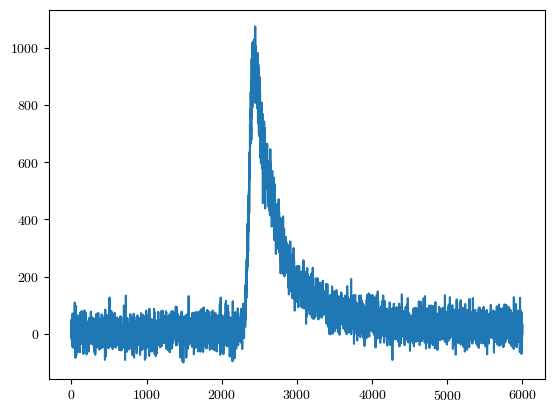

In [262]:
plt.plot(np.nansum(I_corrected, axis=0))

In [264]:
print(I_corrected.shape)

(1024, 6000)


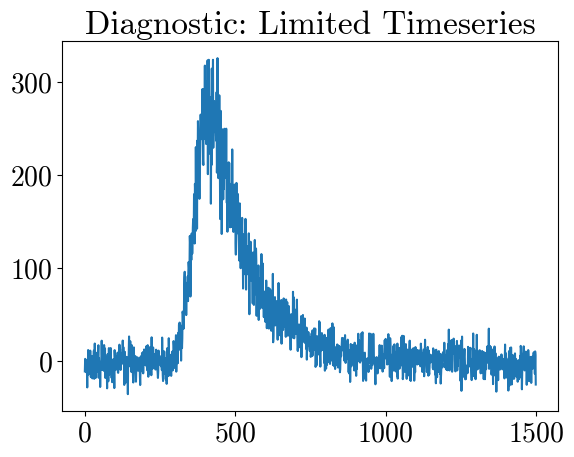

100%|██████████| 128/128 [00:00<00:00, 44609.13it/s]


[[Model]]
    Model(lorentz)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 147
    # data points      = 32
    # variables        = 3
    chi-square         = 0.07593955
    reduced chi-square = 0.00261861
    Akaike info crit   = -187.393714
    Bayesian info crit = -182.996506
    R-squared          = 0.68752360
[[Variables]]
    gamma1:  130.759915 +/- 39.5636672 (30.26%) (init = 1)
    m1:      0.56573232 +/- 0.04917776 (8.69%) (init = 1)
    c:       0.10329909 +/- 0.02252072 (21.80%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(gamma1, c)  = -0.7842
    C(gamma1, m1) = -0.6939
    C(m1, c)      = +0.2036


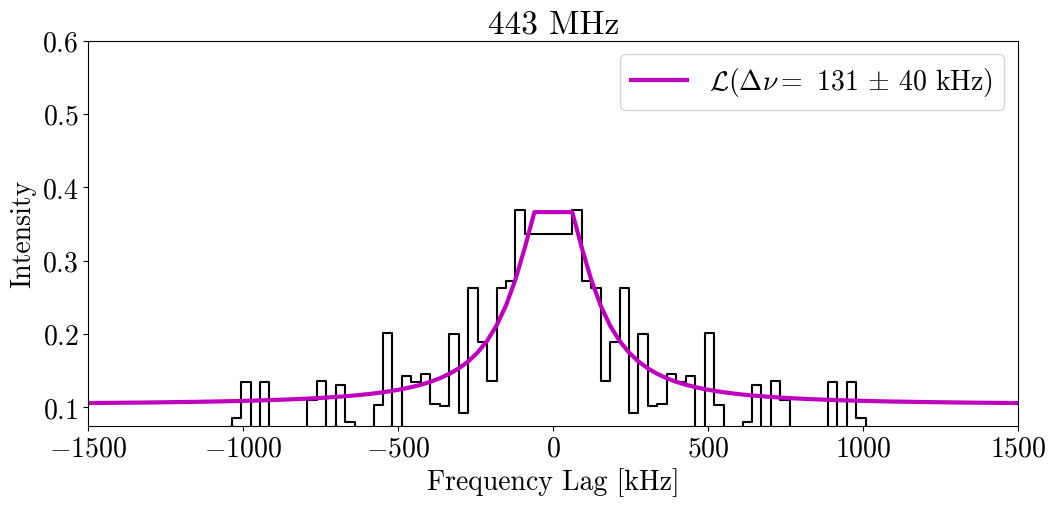

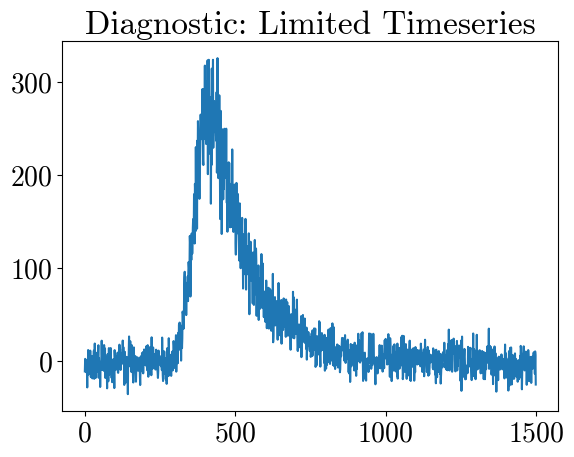

100%|██████████| 128/128 [00:00<00:00, 46526.64it/s]


[[Model]]
    Model(lorentz)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 139
    # data points      = 32
    # variables        = 3
    chi-square         = 0.07660484
    reduced chi-square = 0.00264155
    Akaike info crit   = -187.114591
    Bayesian info crit = -182.717383
    R-squared          = 0.67682834
[[Variables]]
    gamma1:  132.238453 +/- 40.9313469 (30.95%) (init = 1)
    m1:      0.55877846 +/- 0.04918875 (8.80%) (init = 1)
    c:       0.10892377 +/- 0.02282701 (20.96%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(gamma1, c)  = -0.7865
    C(gamma1, m1) = -0.6847
    C(m1, c)      = +0.1943


In [ ]:
rcParams['font.size'] = 20
f = 377
for i in np.arange(0, 6):
    #spec_norm = spectrum / np.max(spectrum)
    intensity_scint = I_corrected
    intensity_tshape = intensity_scint.shape[1]
    intensity_off = intensity_scint[i:i+128, 0:1500]
    offspec_mean = np.nanmean(intensity_off)
    outer_bound = 5
    #spectrum_lim = np.nansum(intensity[i:i+256, intensity_tshape//2 - outer_bound:intensity_tshape//2 + outer_bound], axis=1)
    spectrum_lim = np.nansum(intensity_scint[i:i+128, 2000:3500], axis=1)

    fig = plt.figure()
    #plt.plot(np.nansum(intensity[i:i+256, intensity_tshape//2 - outer_bound:intensity_tshape//2 + outer_bound], axis=0))
    plt.plot(np.nansum(intensity_scint[i:i+128, 2000:3500], axis=0))
    plt.title('Diagnostic: Limited Timeseries')
    plt.show()

    spec_norm = spectrum_lim #/ np.max(spectrum_lim)
    acf=sct.autocorr(spec_norm, offspec_mean = offspec_mean)
    lags=np.arange(len(acf))+1
    acf=acf[1:]
    lags=lags[1:]
    acf=np.concatenate((acf[::-1],acf))
    lags=np.concatenate((-1*lags[::-1],lags))*fres_kHz

    lag_range_for_fit=500 #somewhat arbitrary, 2000 works well to successfully fit the central peak

    gmodel = Model(sct.lorentz)
    acf_for_fit = acf[int(len(acf)/2.)-int(lag_range_for_fit/fres_kHz):int(len(acf)/2.)+int(lag_range_for_fit/fres_kHz)]
    lags_for_fit = lags[int(len(acf)/2.)-int(lag_range_for_fit/fres_kHz):int(len(acf)/2.)+int(lag_range_for_fit/fres_kHz)]
    #result = gmodel.fit(acf_for_fit, x=lags_for_fit, gamma1=10, m1=1,gamma2=100,m2=1, c=0)
    result = gmodel.fit(acf_for_fit, x=lags_for_fit, gamma1=1, m1=1,c=0)
    print(result.fit_report())

    fig = plt.figure(figsize = (12, 5))

    ax = plt.gca()
    ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.xaxis.get_major_formatter().set_scientific(True)
    ax.xaxis.get_major_formatter().set_powerlimits((-4, 4))

    label_str = r'$\mathcal{L}(\Delta \nu =$ ' + str(round(result.params['gamma1'].value)) + r' $\pm$ ' + str(round(result.params['gamma1'].stderr)) + ' kHz)'


    plt.step(lags, acf, c = 'k')
    plt.plot(lags, sct.lorentz(lags, result.params['gamma1'], result.params['m1'], result.params['c']), c = 'm', lw = 3, label = label_str)
    plt.plot(lags, acf - sct.lorentz(lags, result.params['gamma1'], result.params['m1'], result.params['c']) - 0.1, c = 'm', alpha = 0.3, lw = 3)

    plt.xlim(-0.15e4, 0.15e4)
    plt.ylim(0.075, 0.6)
    f = f+66
    plt.title(f'{f} MHz')
    plt.xlabel('Frequency Lag [kHz]')
    plt.ylabel('Intensity')
    plt.legend()
    fig.savefig(f'spec{f}.png')
    #fig.savefig(f'/media/ubuntu/ssd/jfaber/dsa110-scat/codetections/figures/{name.split("_")[0]}/{name}_acf_fit.pdf', bbox_inches = 'tight')
    plt.show()

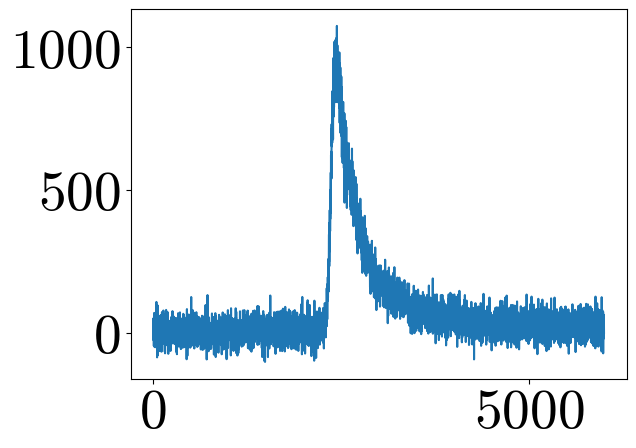

In [227]:
plt.plot(np.nansum(I_corrected, axis=0))


In [229]:
#no upchannelisation
lim = (2100, 4500)
spec = np.nanmean(I_corrected[:,2100:4500],axis=1)
offspec=np.nanmean(I_corrected[:,0:2100],axis=1)

/tmp/ipykernel_780/1368186275.py:3: RuntimeWarning: Mean of empty slice
  spec = np.nanmean(I_corrected[:,2100:4500],axis=1)
/tmp/ipykernel_780/1368186275.py:4: RuntimeWarning: Mean of empty slice
  offspec=np.nanmean(I_corrected[:,0:2100],axis=1)


In [230]:
#downsample in freq
Iscr = scrunch(I_upchan_corrected,tscrunch=1,fscrunch=256)

(120.0, 250.0)

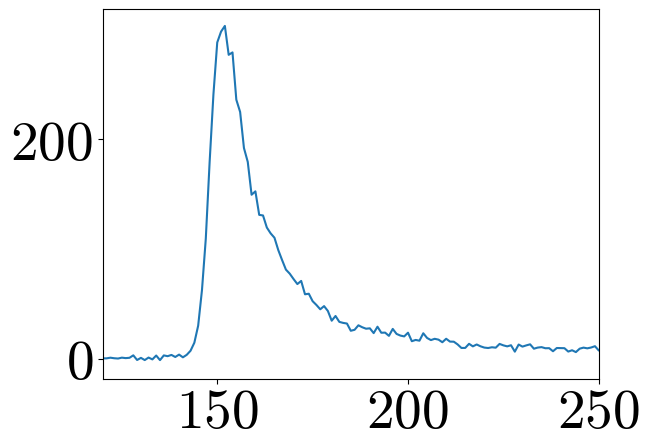

In [234]:
plt.plot(np.nansum(Iscr, axis =0))
plt.xlim(120, 250)

In [235]:
#normalise the prof and spec for plotting
prof=np.nanmean(Iscr,axis=0)
offprof = prof[:80]
prof-=np.nanmean(offprof)
offprof-=np.nanmean(offprof)
prof/=np.nanstd(offprof)

spec_plot = np.nanmean(Iscr[:,120:250],axis=1)
offspec = np.nanmean(Iscr[:,:80],axis=1)

spec_plot-=np.nanmean(offspec)
offspec-=np.nanmean(offspec)
spec_plot/=np.nanstd(offspec)
offspec/=np.nanstd(offspec)

In [236]:
mods=mods_alternative
mod_uncert=mods_alternative_uncert

(2000.0, 4600.0)

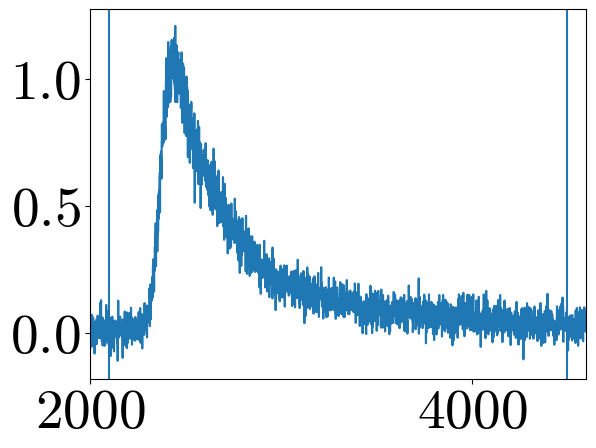

In [240]:
#no upchannelisation
plt.plot(np.nanmean(I_corrected,axis=0), drawstyle='steps-mid')
st_tbin = 2100
end_tbin = 4500
lim=np.array([st_tbin, end_tbin])
plt.axvline(lim[0])
plt.axvline(lim[1])
plt.xlim(2000, 4600)

In [241]:
#upchan
fftsize=512
downfreq=1
data_dedisp_masked_upchan_512 = upchan(data,freqid,fftsize=fftsize,downfreq=downfreq)
#upchannel the noise to model the scalloping
noise_dedisp_masked_upchan_512 = upchan(data_off,freqid,fftsize=fftsize,downfreq=downfreq)

model_512, inds_512 = make_scallop_model(noise_dedisp_masked_upchan_512[0], fftsize, downfreq)

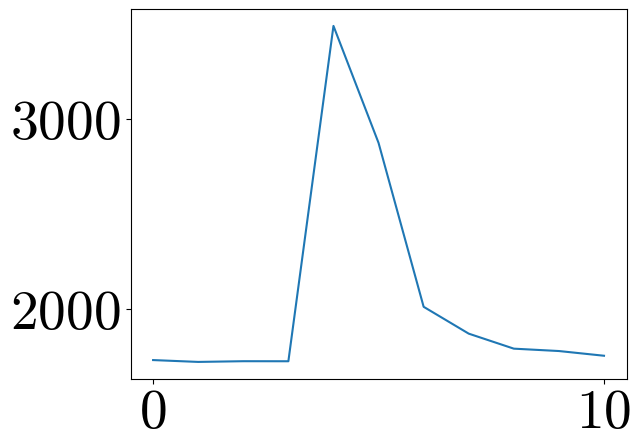

In [246]:
power_512 = np.abs(data_dedisp_masked_upchan_512[0]**2)
I_512 = np.sum(power_512,axis=0).T
plt.close('all')
plt.plot(np.nanmean(I_512,axis=0))
#plt.xlim(3, 7)

In [245]:
burst_peak_512 = 4

In [247]:
#uncorrected upchan
spec_upchan=np.nanmean(I_512[:,burst_peak_512:burst_peak_512+1],axis=1)
spec_upchan[np.isnan(spec_upchan)]=0
spec_upchan[inds_512]=0
spec_upchan=np.ma.masked_where(spec_upchan==0,spec_upchan)

spec_fake_upchan = np.nanmean(I_512[:,0:2],axis=1)
spec_fake_upchan[np.isnan(spec_fake_upchan)]=0
#spec_fake_upchan[inds_512]=0
spec_fake_upchan=np.ma.masked_where(spec_fake_upchan==0,spec_fake_upchan)

In [248]:
#per channel I want to remove the scalloping and normalise using off burst data
I_512upchan_corrected = np.zeros_like(I_512)
for time_bin in range(I_512.shape[1]):
    I_512upchan_corrected[:,time_bin] = I_512[:,time_bin]/model_512
    
    
for freq_chan in range(I_512upchan_corrected.shape[0]):
    Ioff=I_512upchan_corrected[freq_chan,:2]
    I_512upchan_corrected[freq_chan,:] = I_512upchan_corrected[freq_chan,:] - np.nanmean(Ioff)
    Ioff-=np.nanmean(Ioff)
    I_512upchan_corrected[freq_chan,:] = I_512upchan_corrected[freq_chan,:] / np.nanstd(Ioff)
    

In [ ]:
for freq_chan in range(I_on.shape[0]):

In [252]:
spec_upchan_corr=np.nanmean(I_512upchan_corrected[:,6:8],axis=1)
spec_upchan_corr[np.isnan(spec_upchan_corr)]=0
spec_upchan_corr[inds_512]=0
spec_upchan_corr=np.ma.masked_wheere(spec_upchan_corr==0,spec_upchan_corr)

spec_fake_upchan_corr = np.nanmean(I_512upchan_corrected[:,0:5],axis=1)
spec_fake_upchan_corr[np.isnan(spec_fake_upchan_corr)]=0
spec_fake_upchan_corr[inds_512]=0
spec_fake_upchan_corr=np.ma.masked_where(spec_fake_upchan_corr==0,spec_fake_upchan_corr)

calib_off=spec_fake_upchan_corr-np.nanmean(spec_fake_upchan_corr)
calib_off/=np.std(calib_off)
newinds=np.where(np.abs(calib_off)>3)[0]


/tmp/ipykernel_780/3228935346.py:1: RuntimeWarning: Mean of empty slice
  spec_upchan_corr=np.nanmean(I_512upchan_corrected[:,6:8],axis=1)
/tmp/ipykernel_780/3228935346.py:6: RuntimeWarning: Mean of empty slice
  spec_fake_upchan_corr = np.nanmean(I_512upchan_corrected[:,0:5],axis=1)


In [253]:
#let's do some additional flagging determined by making ACFs of the off burst data

spec_fake_upchan_corr[newinds]=0
spec_upchan_corr[newinds]=0

#flagging visibly bad frequency ranges
spec_fake_upchan_corr[np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-501.76))-4096:np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-501.76))+4096]=0
spec_fake_upchan_corr[np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-504.88))-4096:np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-504.88))+4096]=0
spec_fake_upchan_corr[np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-492.38))-4096:np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-492.38))+4096]=0
spec_fake_upchan_corr[np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-643.75))-4096:np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-643.75))+4096]=0
spec_fake_upchan_corr[np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-602.35))-4096:np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-602.35))+4096]=0

spec_fake_upchan_corr=np.ma.masked_where(spec_fake_upchan_corr==0,spec_fake_upchan_corr)


spec_upchan_corr[np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-501.76))-4096:np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-501.76))+4096]=0
spec_upchan_corr[np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-504.88))-4096:np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-504.88))+4096]=0
spec_upchan_corr[np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-492.38))-4096:np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-492.38))+4096]=0
spec_upchan_corr[np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-643.75))-4096:np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-643.75))+4096]=0
spec_upchan_corr[np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-602.35))-4096:np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-602.35))+4096]=0

spec_upchan_corr=np.ma.masked_where(spec_upchan_corr==0,spec_upchan_corr)


ValueError: x and y must have same first dimension, but have shapes (34,) and (1024,)

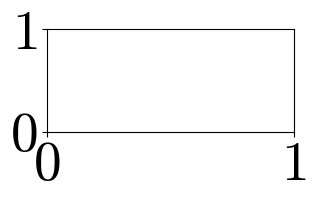

In [254]:
rows = 3
cols = 2
fig = plt.figure(figsize=(7,4))
gs = gridspec.GridSpec(ncols=cols, nrows=rows, width_ratios=[1,1], height_ratios=[1,1,1], wspace=0.2, hspace=0)

ax1 = fig.add_subplot(gs[0,0])
ax1.plot(freq,spec,color='k',lw=0.8,label='on burst')
ax1.plot(freq,offspec,color='mediumseagreen',alpha=1,lw=0.8, label='off burst')
ax1.set_xlim(400,800)
ax1.legend()
ax1.set_ylabel('Total intensity\n [S/N]')
plt.setp(ax1.get_xticklabels(), visible=False)
ax1.axvspan(472,477,color='yellow')
t=ax1.text(.04, .93, 'a', ha='left', va='top', transform=ax1.transAxes,fontsize=8,fontweight='bold')
t.set_bbox(dict(facecolor='white', alpha=1, edgecolor='white'))

ax2 = fig.add_subplot(gs[1,0],sharex=ax1)
ax2.plot(data_dedisp_masked_upchan_512[1],spec_upchan/np.max(spec_fake_upchan),color='k',lw=0.5,label='on burst')
ax2.plot(data_dedisp_masked_upchan_512[1],spec_fake_upchan/np.max(spec_fake_upchan),color='mediumseagreen',alpha=1,lw=0.5, label='off burst')
ax2.set_ylabel('Total intensity\n [arb. units]')
plt.setp(ax2.get_xticklabels(), visible=False)
ax2.axvspan(472,477,color='yellow')
t=ax2.text(.04, .93, 'c', ha='left', va='top', transform=ax2.transAxes,fontsize=8,fontweight='bold')
t.set_bbox(dict(facecolor='white', alpha=1, edgecolor='white'))

ax3 = fig.add_subplot(gs[2,0],sharex=ax2)
ax3.plot(data_dedisp_masked_upchan_512[1],spec_upchan_corr,color='k',lw=0.5,label='on burst')
ax3.plot(data_dedisp_masked_upchan_512[1],spec_fake_upchan_corr,color='mediumseagreen',alpha=1,lw=0.5, label='off burst')
ax3.set_ylabel('Total intensity\n [S/N]')
ax3.axvspan(472,477,color='yellow')

ax3.set_xlabel('Frequency [MHz]')

t=ax3.text(.04, .93, 'e', ha='left', va='top', transform=ax3.transAxes,fontsize=8,fontweight='bold')
t.set_bbox(dict(facecolor='white', alpha=1, edgecolor='white'))

ax4 = fig.add_subplot(gs[0,1])
ax4.plot(freq,spec,color='k',lw=0.8,label='on burst')
ax4.plot(freq,offspec,color='mediumseagreen',alpha=1,lw=0.8, label='off burst')
ax4.set_xlim(472,477)
ax4.legend()
plt.setp(ax4.get_xticklabels(), visible=False)
t=ax4.text(.04, .93, 'b', ha='left', va='top', transform=ax4.transAxes,fontsize=8,fontweight='bold')
t.set_bbox(dict(facecolor='white', alpha=1, edgecolor='white'))

ax5 = fig.add_subplot(gs[1,1],sharex=ax4)
ax5.plot(data_dedisp_masked_upchan_512[1],spec_upchan/np.max(spec_fake_upchan),color='k',lw=0.2,label='on burst')
ax5.plot(data_dedisp_masked_upchan_512[1],spec_fake_upchan/np.max(spec_fake_upchan),color='mediumseagreen',alpha=1,lw=0.5, label='off burst')
ax5.plot(data_dedisp_masked_upchan_512[1],model_512/np.max(spec_fake_upchan),color='darkviolet',alpha=1,lw=3, label='scallop model')
ax5.set_ylim(-0.003,0.07)
plt.setp(ax5.get_xticklabels(), visible=False)
t=ax5.text(.04, .93, 'd', ha='left', va='top', transform=ax5.transAxes,fontsize=8,fontweight='bold')
t.set_bbox(dict(facecolor='white', alpha=1, edgecolor='white'))

ax6 = fig.add_subplot(gs[2,1],sharex=ax5)
ax6.plot(data_dedisp_masked_upchan_512[1],spec_upchan_corr,color='k',lw=0.5,label='on burst')
ax6.plot(data_dedisp_masked_upchan_512[1],spec_fake_upchan_corr,color='mediumseagreen',alpha=1,lw=0.5, label='off burst')
ax6.set_ylim(-2,8.1)


ax6.set_xlabel('Frequency [MHz]')
t=ax6.text(.04, .93, 'f', ha='left', va='top', transform=ax6.transAxes,fontsize=8,fontweight='bold')
t.set_bbox(dict(facecolor='white', alpha=1, edgecolor='white'))

fig.tight_layout(pad=1)
#plt.savefig('./spectrum_pa_swing.final.jpg',format='jpg',dpi=300)


plt.show()

In [260]:
print(spec_upchan_corr.shape)

(524288,)


In [255]:
#let's do some additional flagging determined by making ACFs of the off burst data

spec_fake_upchan_corr[newinds]=0
spec_upchan_corr[newinds]=0

#flagging visibly bad frequency ranges
spec_fake_upchan_corr[np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-501.76))-4096:np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-501.76))+4096]=0
spec_fake_upchan_corr[np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-504.88))-4096:np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-504.88))+4096]=0
spec_fake_upchan_corr[np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-492.38))-4096:np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-492.38))+4096]=0
spec_fake_upchan_corr[np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-643.75))-4096:np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-643.75))+4096]=0
spec_fake_upchan_corr[np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-602.35))-4096:np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-602.35))+4096]=0

spec_fake_upchan_corr=np.ma.masked_where(spec_fake_upchan_corr==0,spec_fake_upchan_corr)


spec_upchan_corr[np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-501.76))-4096:np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-501.76))+4096]=0
spec_upchan_corr[np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-504.88))-4096:np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-504.88))+4096]=0
spec_upchan_corr[np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-492.38))-4096:np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-492.38))+4096]=0
spec_upchan_corr[np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-643.75))-4096:np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-643.75))+4096]=0
spec_upchan_corr[np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-602.35))-4096:np.argmin(np.abs(noise_dedisp_masked_upchan_512[1]-602.35))+4096]=0

spec_upchan_corr=np.ma.masked_where(spec_upchan_corr==0,spec_upchan_corr)


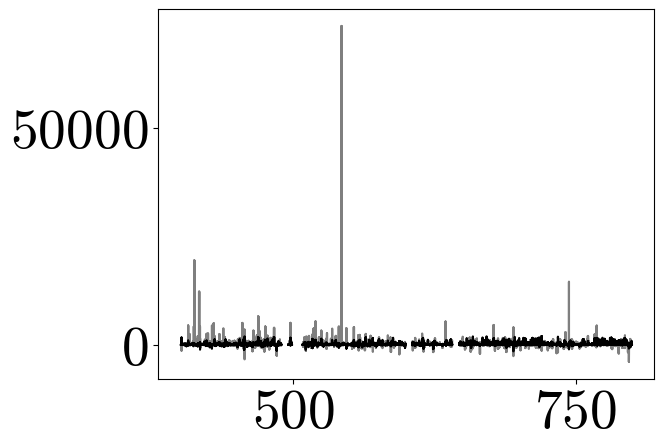

In [256]:
plt.plot(data_dedisp_masked_upchan_512[1],spec_upchan_corr,color='k',alpha=0.5)
plt.plot(data_dedisp_masked_upchan_512[1],spec_fake_upchan_corr,color='k')

In [259]:
acfs,fcents,lags, subsn, submask,spec_lens=acf_per_subband(spec_upchan_corr,data_dedisp_masked_upchan_512[1],data_dedisp_masked_upchan_512[2],num_subbands=8,plot_fit=True,maxlag=1000,offspec=spec_fake_upchan_corr,snsubband=True)


beg,end 0 110760
Frequency resolution is 0.00076 MHz


 13%|█▎        | 14865/110760 [00:12<01:17, 1235.86it/s]


KeyboardInterrupt: 

$L_x L_g \lesssim \frac{D_s^2}{2 \pi \nu^2(1+z)} \frac{\nu_{\mathrm{DC}}}{t_{\text {scatt }}}$.

In [18]:
def Lx(nu, dso, z, sbw, tau, Lg):
    lx = (dso**2 * sbw) / (Lg * (2 * np.pi * nu**2) * (1+z) * tau)
    return lx

with open(f'/media/ubuntu/ssd/jfaber/dsa110-scat/codetections/localizations/dsa_localizations.json', 'r') as file:
    loc_data = json.load(file)

#localization = ['20h50m28.59s', '+73d54m00.0s']
#z_source = 0.0740
localization = [loc_data[f'{name.split("_")[0]}']["localization"]["ra"], loc_data[f'{name.split("_")[0]}']["localization"]["dec"]]
#z_source = loc_data[f'{name.split("_")[0]}']["z_source"]
z_source = 0.239 # corresponds to a comoving distance of 1 Gpc
print('localization:', localization)
print('z_source:', z_source)

gal_dist = 30 #kpc
coord_icrs = SkyCoord(localization[0], localization[1], frame = 'icrs')
coord_galactic = coord_icrs.galactic
ra_gal_deg = coord_galactic.l.deg
dec_gal_deg = coord_galactic.b.deg
output = get_dm_full(ra_gal_deg, dec_gal_deg, gal_dist)

print('NE2001 Sightline Estimates:')
print('________________________________')
ne2001_sbw_1p4GHz = output["SBW"]*(1.4)**best_fit_params_dict["alpha"][0]
print(f'SBW (1.4 GHz): {1e3*ne2001_sbw_1p4GHz} kHz')
ne2001_tau_1p4GHz = output["TAU"]*(1.4)**(-1 * best_fit_params_dict["alpha"][0])
print(f'Tau (1.4 GHz): {ne2001_tau_1p4GHz} ms')
print('\n')

# Perform two-screen calculation
print('Two Screen Analysis:')
print('________________________________')
# Define a cosmology, e.g., H0 = 70 km/s/Mpc and Omega_m = 0.3
H0 = 70
Om0 = 0.3
cosmo = FlatLambdaCDM(H0=H0, Om0=Om0)
#dso = cosmo.comoving_distance(z_source).to(u.kpc) # comoving distance
dso = 1*u.Gpc
print(f'Comoving Distance to Source: {dso}')
sbw_1p4GHz = result.params['gamma1'].value * u.kHz
print(f'Measured SBW (1.4 GHz): {sbw_1p4GHz}')
nu = (1.4 * u.GHz).to(u.kHz)
print(f'Observing Frequency: {nu}')
tau_1p4GHz = best_fit_params_dict['tau_1GHz'][0] * 1.4**(-1*best_fit_params_dict['alpha'][0]) * u.ms
print(f'Measured Tau (1.4 GHz): {tau_1p4GHz}')
lg = 1 * u.kpc
print(f'L_g (MW Thick Disk): {lg}')
lx = Lx(nu, dso, z_source, sbw_1p4GHz, tau_1p4GHz, lg)
lx_kpc = lx.to(u.kpc)
print(f'Upper Limit on Source-to-Screen Distance: {lx_kpc}')



localization: ['05h52m45.12s', '+74d12m01.7s']
z_source: 0.239
NE2001 Sightline Estimates:
________________________________
SBW (1.4 GHz): 1260.8131200000971 kHz
Tau (1.4 GHz): 0.00014642336526446184 ms


Two Screen Analysis:
________________________________
Comoving Distance to Source: 1.0 Gpc
Measured SBW (1.4 GHz): 33.896493169002476 kHz
Observing Frequency: 1400000.0 kHz
Measured Tau (1.4 GHz): 0.05245390441138955 ms
L_g (MW Thick Disk): 1.0 kpc
Upper Limit on Source-to-Screen Distance: 42.35158839068933 kpc


In [24]:
two_screen_dict = {}
two_screen_dict["localization"] = localization
two_screen_dict["z_source"] = z_source
two_screen_dict["cosmology"] = [H0, Om0]
two_screen_dict["comoving_distance"] = dso.value
two_screen_dict["ra_gal"] = ra_gal_deg
two_screen_dict["dec_gal"] = dec_gal_deg
two_screen_dict["ne2001_fulldict"] = output
two_screen_dict["ne2001_sbw_1.4GHz"] = ne2001_sbw_1p4GHz
two_screen_dict["ne2001_tau_1.4GHz"] = ne2001_tau_1p4GHz
two_screen_dict["sbw_1.4GHz"] = sbw_1p4GHz.value
two_screen_dict["tau_1.4GHz"] = tau_1p4GHz.value
two_screen_dict["L_G"] = lg.value
two_screen_dict["L_X"] = lx_kpc.value

best_fit_params_dict["two_screen"] = two_screen_dict


In [25]:
with open(f'/media/ubuntu/ssd/jfaber/dsa110-scat/codetections/params/{name.split("_")[0]}_best_fit_params.json', 'w') as f:
    json.dump(best_fit_params_dict, f)